# Import Libraries and packages

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(
    { "figure.figsize": (8, 5) },
    style='ticks',
    color_codes=True,
    font_scale=1
)
%config InlineBackend.figure_format = 'retina'

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

!pip install category_encoders -q
!pip install xgboost

# ML utilities
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn import metrics

# Models
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

# Encoding and metrics
from category_encoders import TargetEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Loading the dataset

In [4]:
ecom_data = pd.read_csv("../data/Dataset_ecommerce.csv")

# Initial inspection of the dataset

In [6]:
ecom_data.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,536365,2010-12-01 08:26:00,17850.0,SC1734,Electronics,65,10.23,Egypt
1,536365,2010-12-01 08:26:00,17850.0,SC2088,Furniture,95,19.61,Mali
2,536365,2010-12-01 08:26:00,17850.0,SC3463,Books,78,61.49,Mali
3,536365,2010-12-01 08:26:00,17850.0,SC6228,Toys,15,24.73,South Africa
4,536365,2010-12-01 08:26:00,17850.0,SC2149,Toys,50,38.83,Rwanda


In [7]:
ecom_data.sample()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
527113,580694,2011-12-05 16:00:00,16600.0,SC4446,Shoes,59,64.94,Cote d'Ivoire


In [8]:
ecom_data.shape

(541909, 8)

In [9]:
ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   InvoiceDate  541909 non-null  object 
 2   CustomerID   406829 non-null  float64
 3   StockCode    541909 non-null  object 
 4   Description  541909 non-null  object 
 5   Quantity     541909 non-null  int64  
 6   UnitPrice    541909 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### Observation: Sampled Dataset contains 541909 rows and 8 columns in which most of them are strings.

In [11]:
ecom_data.describe(include='all')

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
count,541909,541909,406829.000000,541909,541909,541909.000000,541909.000000,541909
unique,25900,23260,NaN,9000,10,NaN,NaN,28
top,573585,2011-10-31 14:41:00,NaN,SC2014,Sports Equipment,NaN,NaN,Cote d'Ivoire
freq,1114,1114,NaN,96,54765,NaN,NaN,19651
mean,NaN,NaN,15287.690570,NaN,NaN,50.534748,50.476354,NaN
std,NaN,NaN,1713.600303,NaN,NaN,28.849367,28.564775,NaN
min,NaN,NaN,12346.000000,NaN,NaN,1.000000,1.000000,NaN
25%,NaN,NaN,13953.000000,NaN,NaN,26.000000,25.750000,NaN
50%,NaN,NaN,15152.000000,NaN,NaN,51.000000,50.430000,NaN
75%,NaN,NaN,16791.000000,NaN,NaN,76.000000,75.180000,NaN


In [12]:
# Checking Unique values in the columns
print("Unique Customers:", ecom_data['CustomerID'].nunique())
print("Unique Products:", ecom_data['StockCode'].nunique())
print("Countries:", ecom_data['Country'].nunique())

Unique Customers: 4372
Unique Products: 9000
Countries: 28


In [13]:
ecom_data.isnull().sum()

InvoiceNo           0
InvoiceDate         0
CustomerID     135080
StockCode           0
Description         0
Quantity            0
UnitPrice           0
Country             0
dtype: int64

### Observation - The CustomerID column have 135080 null values (missing data).

# Splitting the features to qualitative and quantitative features

In [16]:
# Categorising quantitative features (numerical columns)
numerical_features = ecom_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Categorising qualitative features (categorical columns)
categorical_features = ecom_data.select_dtypes(include=['object', 'bool']).columns.tolist()

In [17]:
numerical_features

['CustomerID', 'Quantity', 'UnitPrice']

In [29]:
categorical_features

['InvoiceNo', 'InvoiceDate', 'StockCode', 'Description', 'Country']

# Data Cleaning & Preprocessing

## Handling missing values, duplicate values and formatting the CustomerID and InvoiceDate 

In [33]:
# the percentage of missing values in each columns
missing_pct = round(ecom_data.isna().sum()/len(ecom_data) * 100, 1)
print(missing_pct)

InvoiceNo       0.0
InvoiceDate     0.0
CustomerID     24.9
StockCode       0.0
Description     0.0
Quantity        0.0
UnitPrice       0.0
Country         0.0
dtype: float64


### Observation - ~25% of the CustomerID values are missing which is a significant portion of the dataset. However, since the goal of the project is churn prediction, it is better to drop rows with missing CustomerID in order to have a clean base of identifiable customers for all the cohort and ML modeling tasks.

In [36]:
# Drop rows with missing CustomerID
ecom_data = ecom_data.dropna(subset=['CustomerID'])

In [38]:
# Confirm if the missing CustomerID are dropped
print(f"Remaining rows: {ecom_data.shape[0]}")
print(f"Missing CustomerID after drop: {ecom_data['CustomerID'].isna().sum()}")

Remaining rows: 406829
Missing CustomerID after drop: 0


In [40]:
# Check number of duplicates before dropping
duplicate_count = ecom_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [42]:
# Convert the CustomerID from float to integer
ecom_data = ecom_data.dropna(subset=['CustomerID'])
ecom_data['CustomerID'] = ecom_data['CustomerID'].astype(int)

In [44]:
# Convert the date format from string to datetime
ecom_data['InvoiceDate'] = pd.to_datetime(ecom_data['InvoiceDate'])

In [46]:
# check the range of dates
print(ecom_data['InvoiceDate'].min(), "to", ecom_data['InvoiceDate'].max())

2010-12-01 08:26:00 to 2011-12-09 12:50:00


# Feature engineering based on domain knowledge

In [49]:
# Create TotalPrice feature
ecom_data['TotalPrice'] = ecom_data['Quantity'] * ecom_data['UnitPrice']

In [51]:
# Extract features such as Invoice Year, Invoice Month and Weekday
ecom_data['InvoiceYear'] = ecom_data['InvoiceDate'].dt.year
ecom_data['InvoiceMonth'] = ecom_data['InvoiceDate'].dt.to_period('M')
ecom_data['Weekday'] = ecom_data['InvoiceDate'].dt.day_name()

In [53]:
ecom_data.head(1)

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,TotalPrice,InvoiceYear,InvoiceMonth,Weekday
0,536365,2010-12-01 08:26:00,17850,SC1734,Electronics,65,10.23,Egypt,664.95,2010,2010-12,Wednesday


# Exploratory Data Analysis

## Sales Trends Over Time

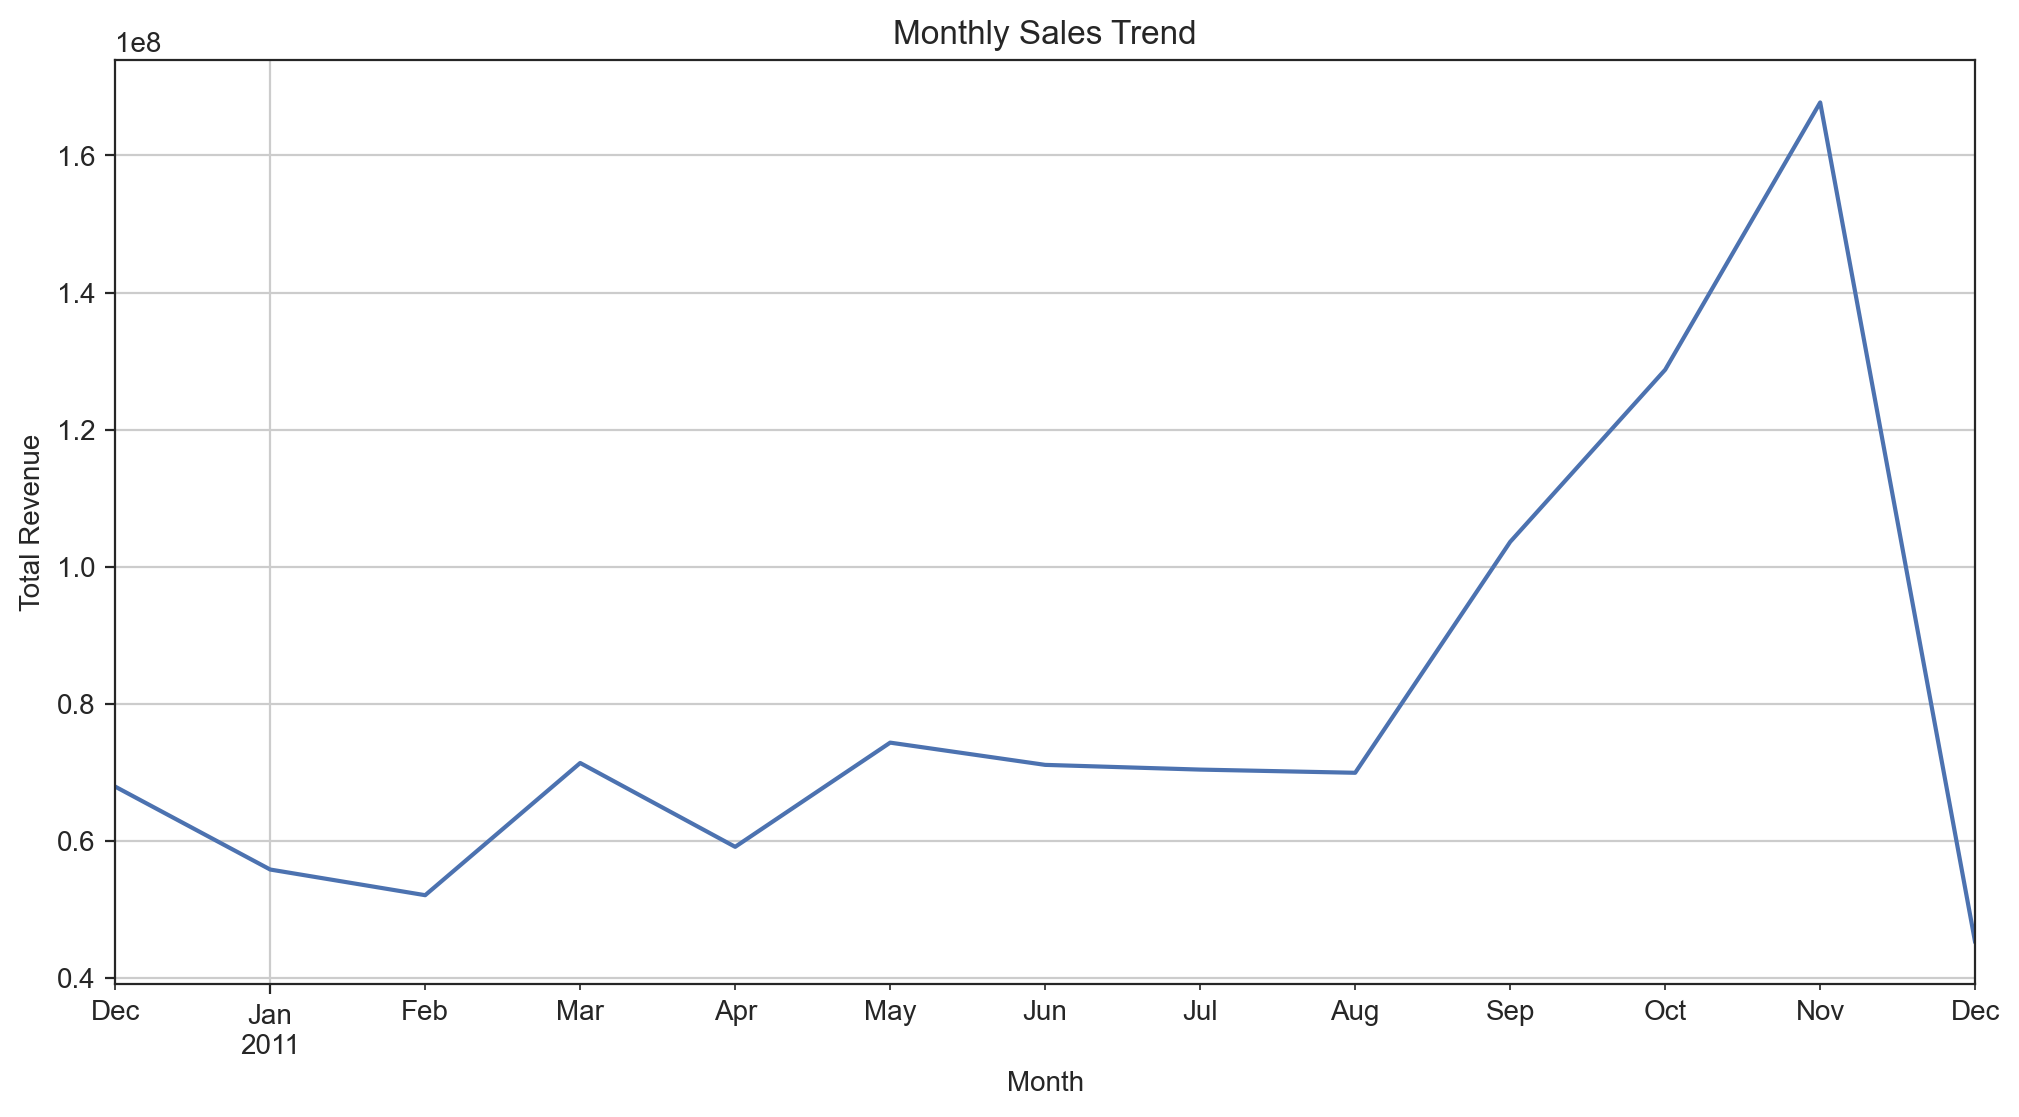

In [61]:
monthly_sales = ecom_data.groupby(ecom_data['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

### Observation - Initial dip: Sales slightly declined from December to February, reaching a low point in February.¶¶
### Moderate Recovery: There was a modest increase in March and May, but the trend remained relatively flat from June to August.
### Strong Growth Phase: Sales began to climb sharply from September to November, peaking in November — the highest revenue month.
### Sharp Drop: A dramatic drop occurred in December, likely due to seasonal closure e.g., holiday break or end of the data collection period.

## Top Selling Products

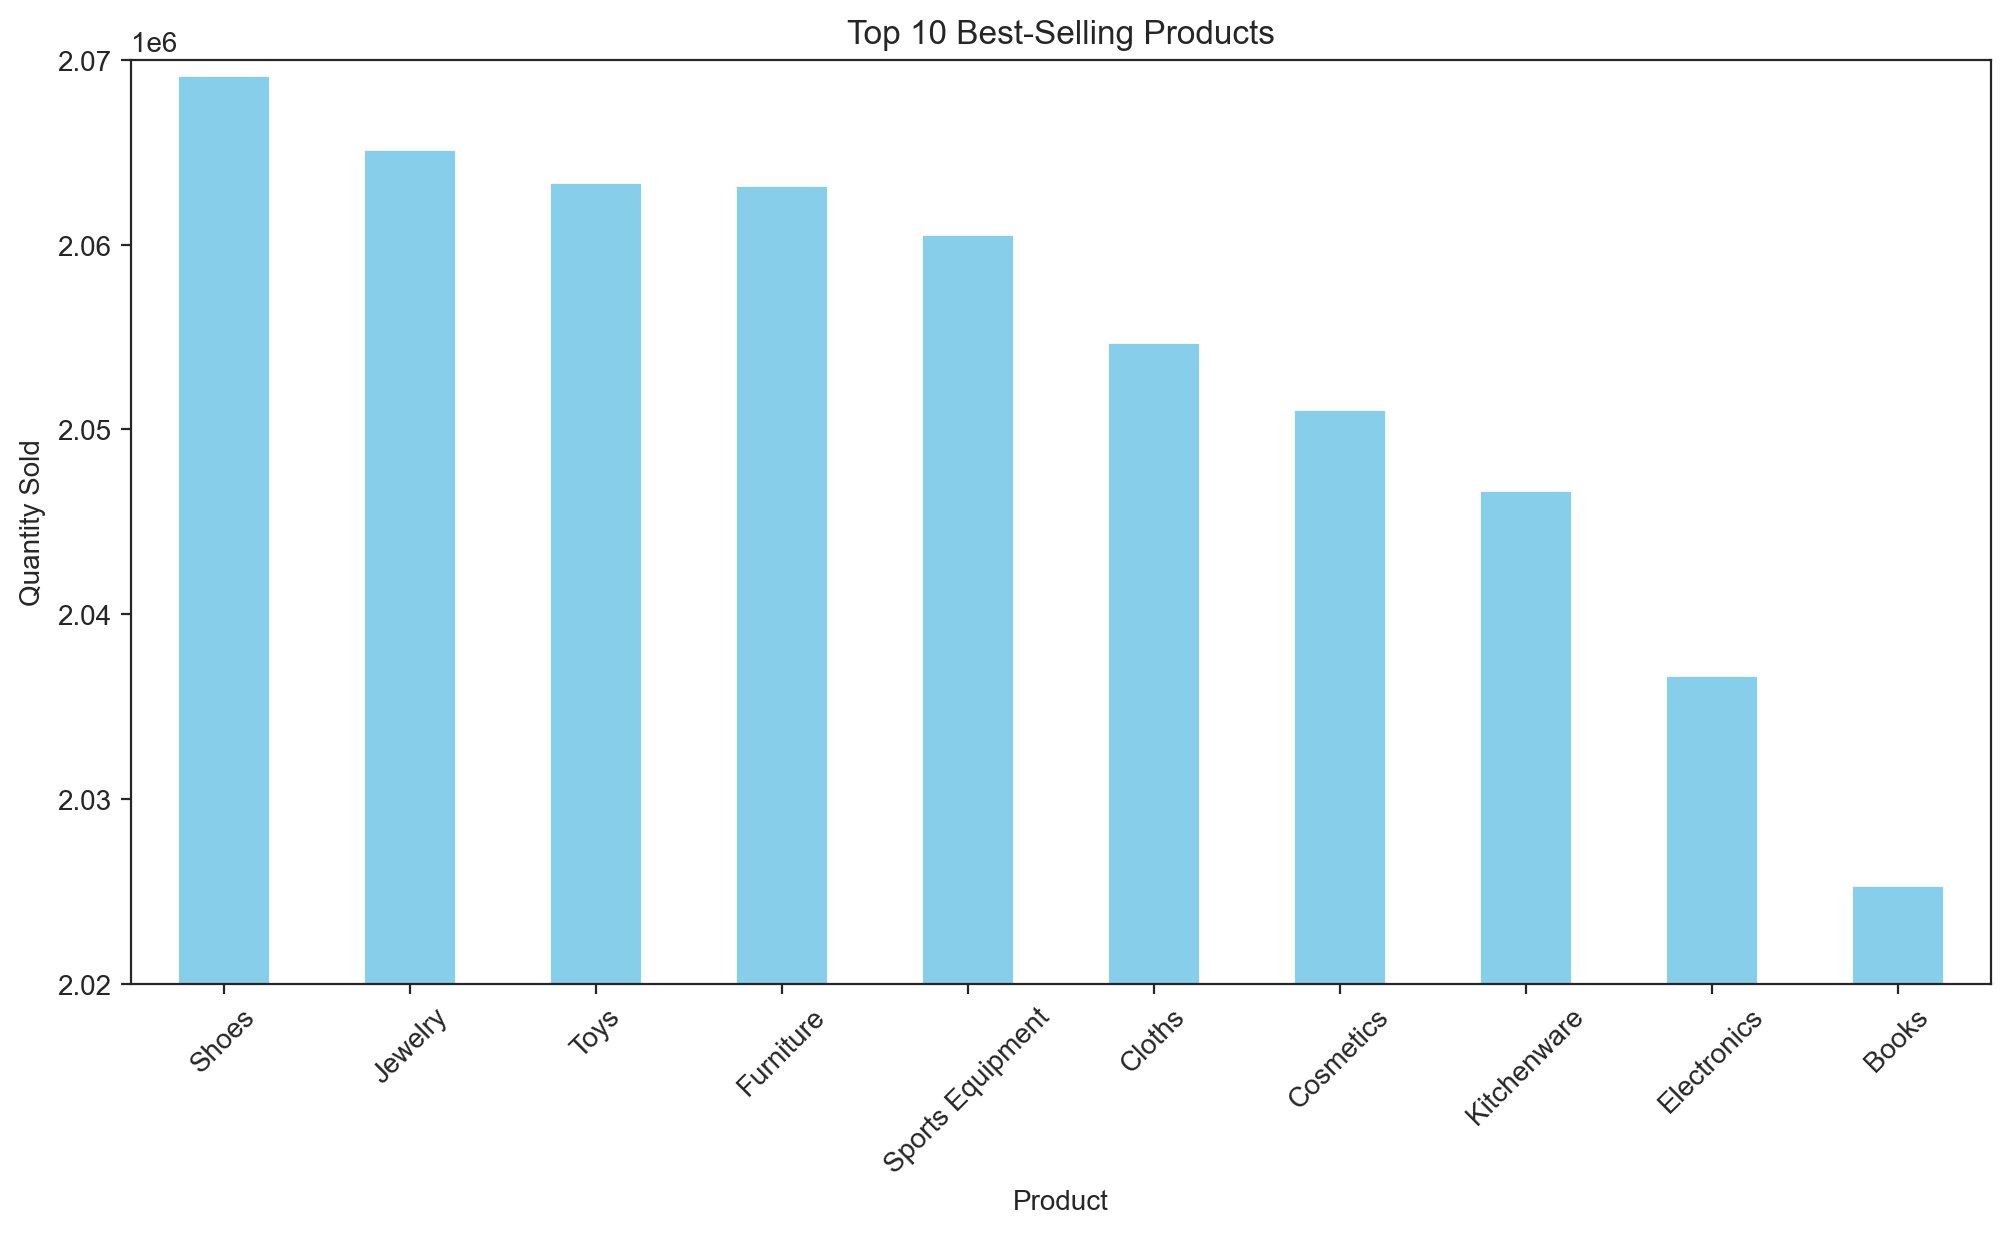

In [65]:
# Total quantity sold per product
top_products = ecom_data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plot
top_products.plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.ylim(2.02e6, 2.07e6)
plt.show()

### The bar chart above highlights the Top 10 Best-Selling Products based on the total quantity sold. 
### - The sales figures across these categories are nearly identical, with each product line approaching 2 million units sold. Shoes lead marginally, followed by Jewelry, Toys, and Furniture, among others.This uniformity suggests a well-diversified product portfolio with balanced consumer demand across different segments. 
### - Such even distribution of sales indicates effective inventory and marketing strategies, reducing over-dependence on any one product. Moreover, this can enhance business resilience and optimize overall performance throughout seasonal or market fluctuations.

## Customer Purchase Behavior

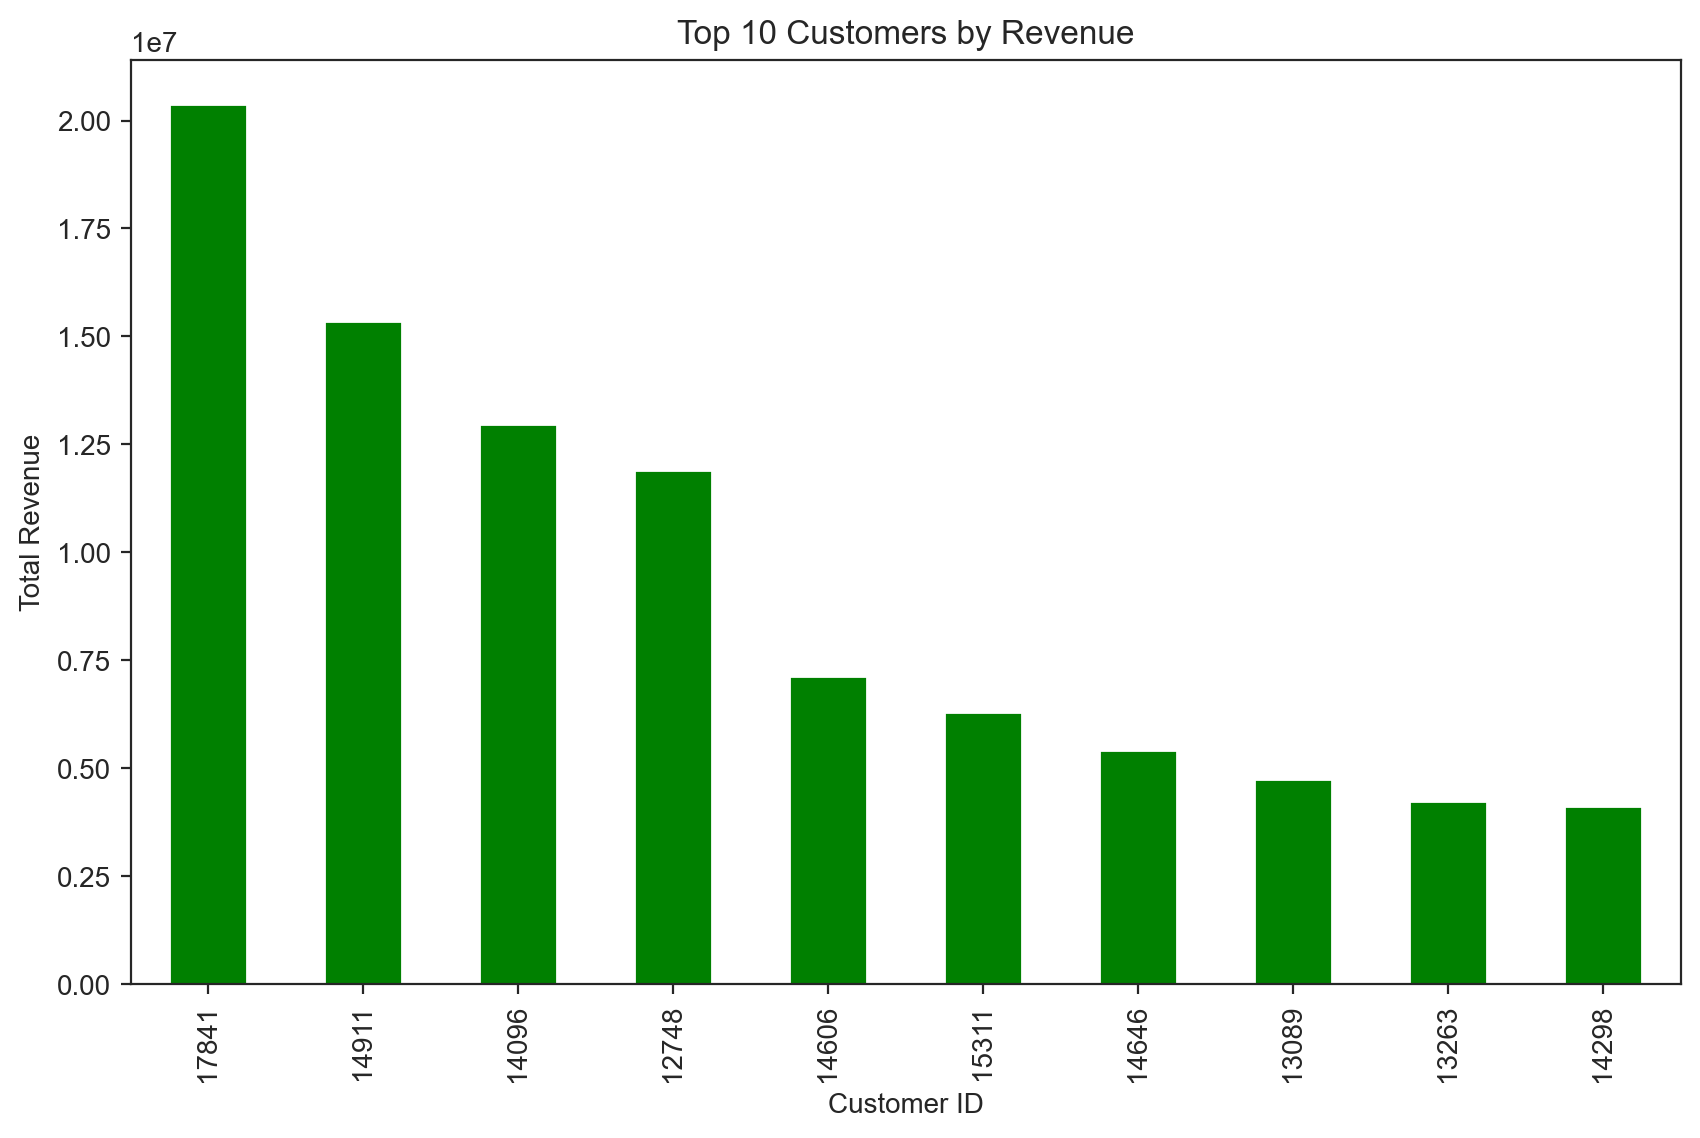

In [45]:
# Total Revenue per Customer
customer_revenue = ecom_data.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

customer_revenue.head(10).plot(kind='bar', figsize=(10,6), color='green')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.show()

### The bar chart visualizes the Top 10 Customers by Total Revenue, highlighting the most valuable clients based on their purchasing behavior.
### - The customer with ID 17841.0 generated the highest revenue, exceeding 20 million in total. This customer stands out significantly compared to the rest, suggesting a very strong transactional relationship.
### - Following this, Customers 14911.0 and 14096.0 also contribute notably, each bringing in revenues between 13 and 15 million respectively.
### - There is a gradual decline in revenue as we move from left to right across the chart. The 10th highest customer (Customer ID 14298.0) still contributed over 5 million, but this is less than one-third of the top customer's contribution.¶
### - Overall, this pattern indicates a concentration of revenue among a few key clients, with a steep revenue drop beyond the top 5.
### Business Insight - The data suggests that a small number of customers account for a disproportionate share of total revenue, with the top 3 customers alone generating a significant chunk. This emphasizes the importance of customer relationship management and retention strategies for these high-value clients. At the same time, there is an opportunity to nurture mid-tier customers (like those ranked 6–10) to increase their spend and move them higher up the revenue ladder.

In [71]:
# Frequency of Purchase
ecom_data['CustomerID'].nunique(), ecom_data['InvoiceNo'].nunique()

(4372, 22190)

In [73]:
ecom_data.groupby('CustomerID')['InvoiceNo'].nunique().max()

248

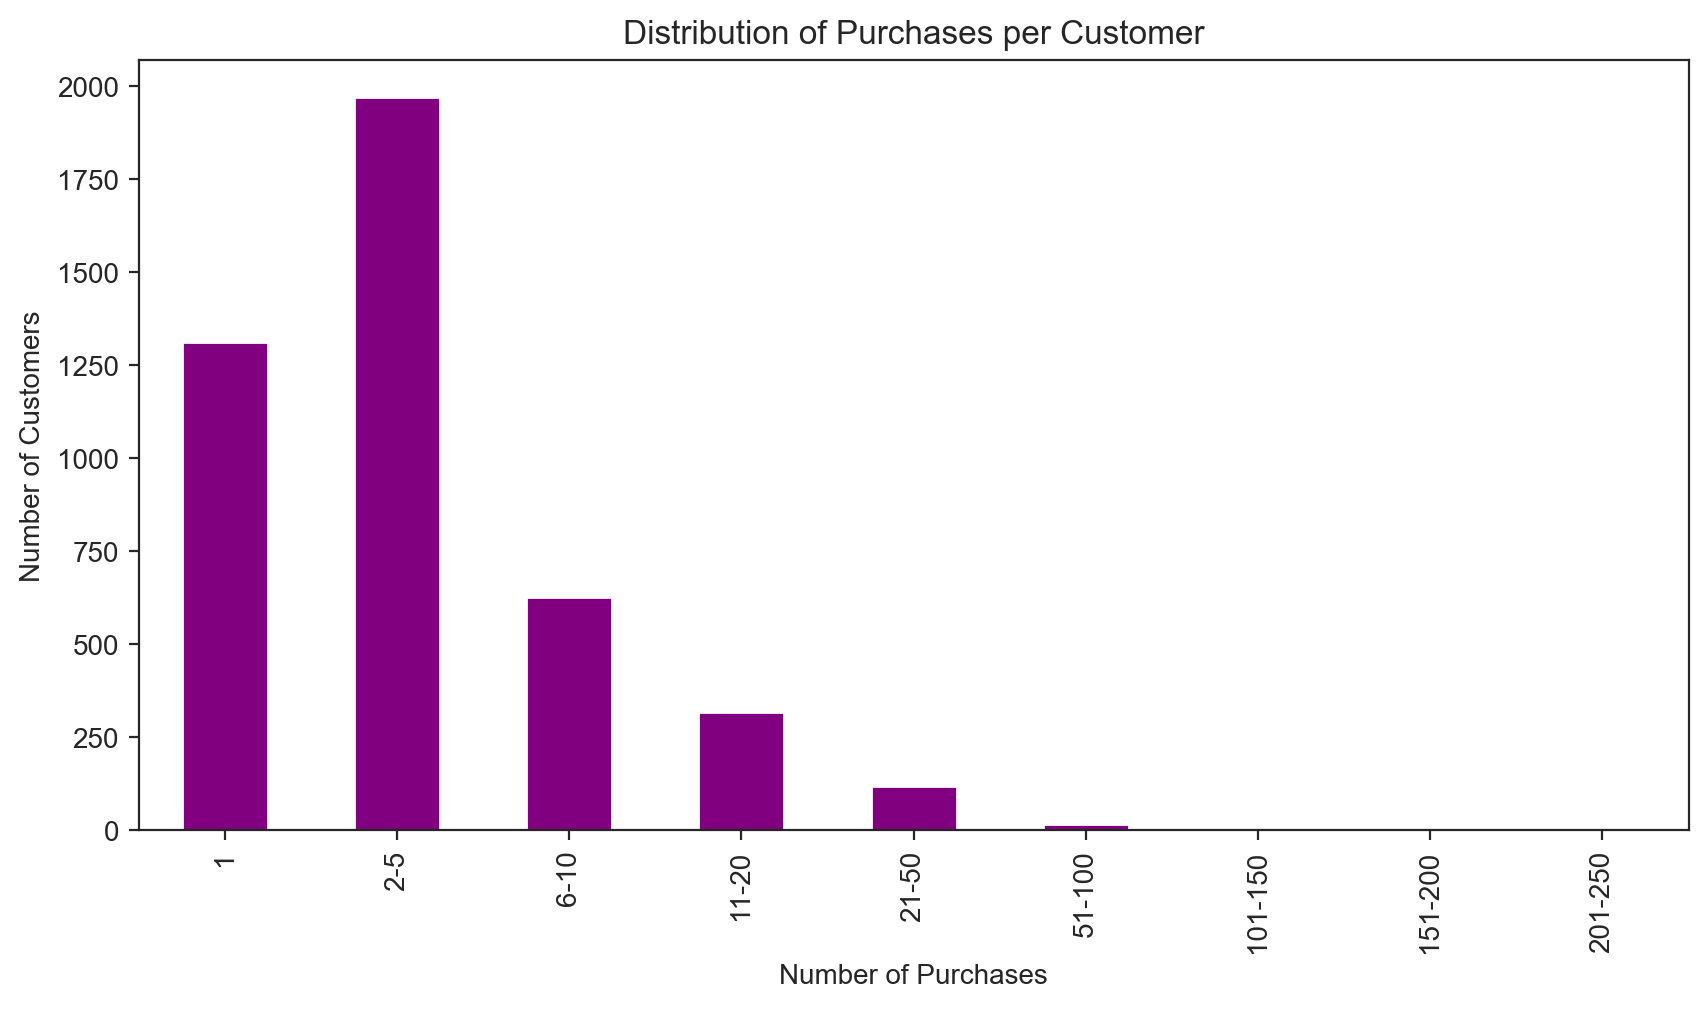

In [75]:
customer_pur_frequency = ecom_data.groupby('CustomerID')['InvoiceNo'].nunique()

# Bin the number of purchases into ranges
bins = [0, 1, 5, 10, 20, 50, 100, 150, 200, 250]
labels = ['1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-150', '151-200', '201-250']
binned = pd.cut(customer_pur_frequency, bins=bins, labels=labels, include_lowest=True)

# Count number of purchases in each bin
purchase_distribution = binned.value_counts().sort_index()

# Plot
plt.figure(figsize=(10,5))
purchase_distribution.plot(kind='bar', color='purple')
plt.title('Distribution of Purchases per Customer')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.show()

### Observation - The bar chart revealed that ~30% of the customer made a single purchase, about 45% of the customer made 2-5 purchases. only about 14% made 6-10 purchases. The chart showed a significant drop-off in the number of customer making more purchases. This indicates that the business is struggling with customer retention.  

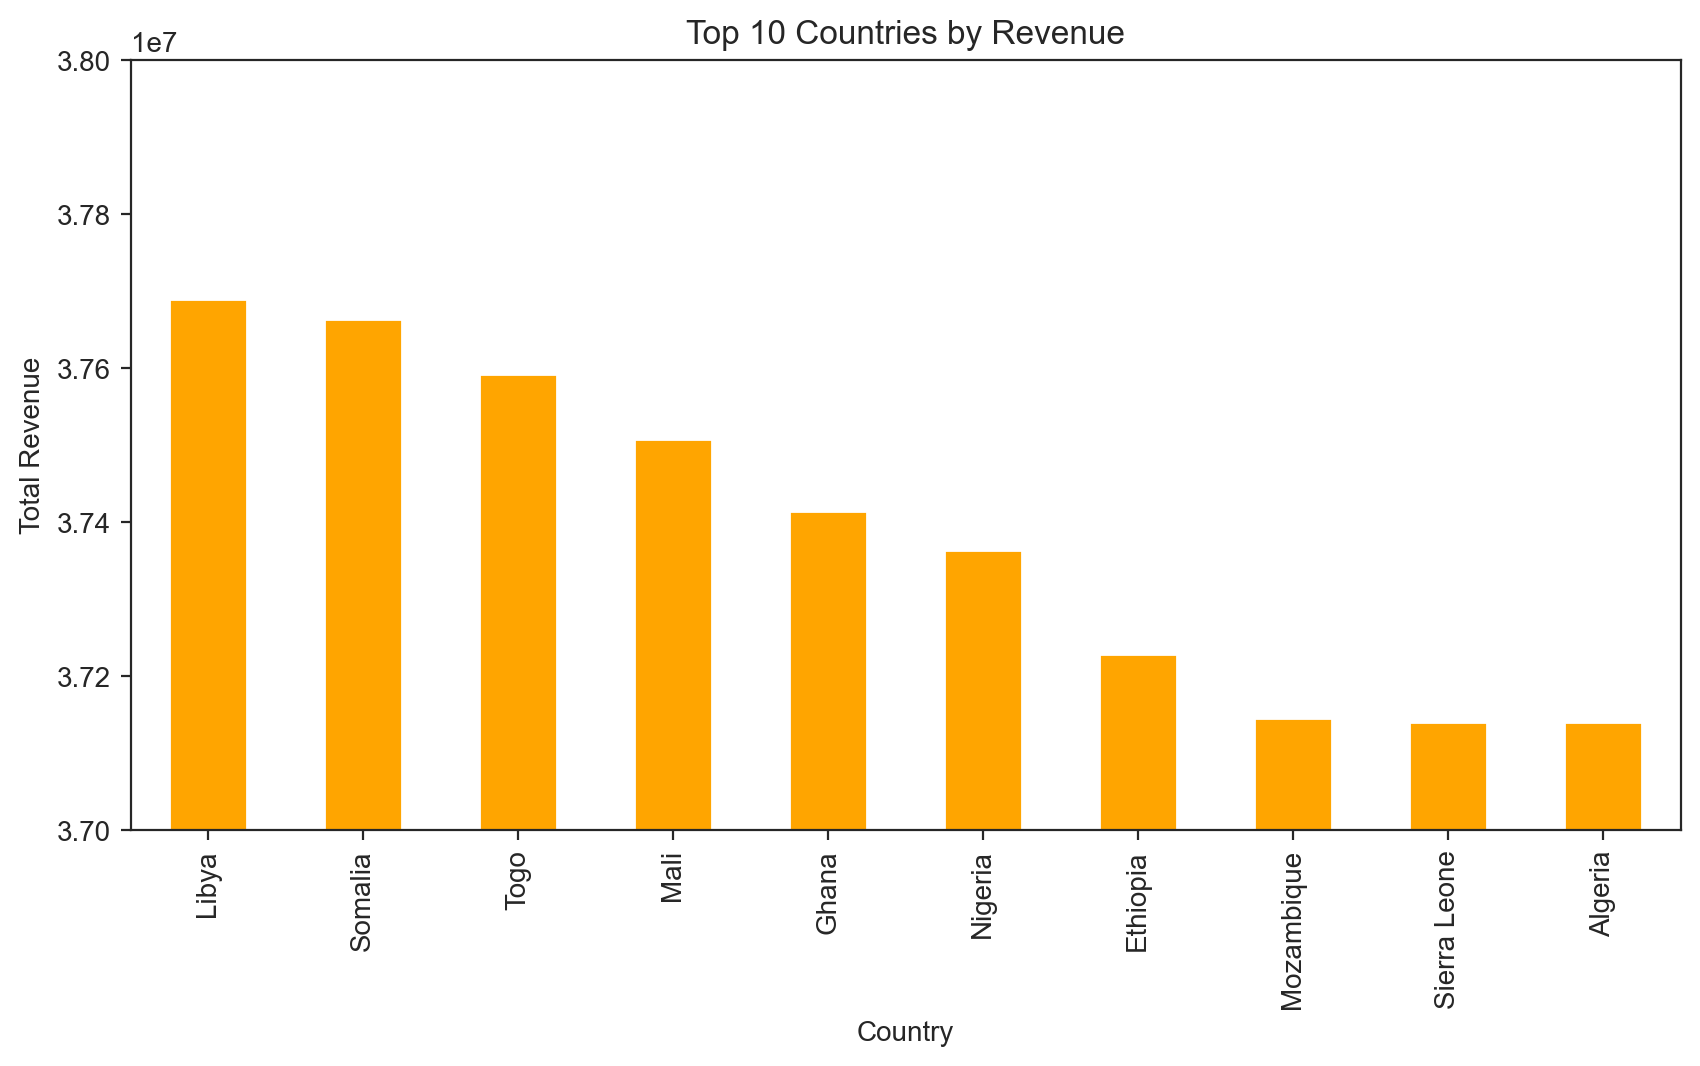

In [80]:
# Sales by Country
country_sales = ecom_data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar', figsize=(10,5), color='orange')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.ylim(3.70e7, 3.80e7)
plt.show()

### - The bar chart visualizes the Top 10 Countries by Total Revenue, highlighting the countries with the highest revenue based on their purchases. 
### - Libya at the top means customers from Libya made the most purchases or bought higher-priced items, followed by Somalia, then Togo, Mali, Ghana, down to Algeria. 
### - Countries at the top might be high-value markets for the business, this can inform targeted marketing strategies, e.g., offer premium services in Libya or Somalia. Interesting many of the top countries are in Africa — this could reflect a niche or regional market the business serves.

# Calculate Recency, Frequency, Monetary and Customer Tenure

In [85]:
# Reference date for Recency (last purchase + buffer)
reference_date = ecom_data['InvoiceDate'].max() + pd.Timedelta(days=7)

In [87]:
# RFM calculation
rfm = ecom_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
})

In [89]:
# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [91]:
# Preview
print(rfm.head())

            Recency  Frequency   Monetary
CustomerID                               
12346           332          2    5342.40
12347             8          7  431501.00
12348            81          4   82378.47
12349            25          1  176075.12
12350           316          1   48173.37


In [93]:
# Group by CustomerID to get first and last purchase dates
cus_tenure = ecom_data.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max']
})

# Rename columns
cus_tenure.columns = ['FirstPurchaseDate', 'LastPurchaseDate']

# Calculate tenure in days
cus_tenure['TenureDays'] = (cus_tenure['LastPurchaseDate'] - cus_tenure['FirstPurchaseDate']).dt.days

In [95]:
# Merge RFM and Tenure into a single DataFrame
cus_feat = rfm.merge(cus_tenure[['TenureDays']], left_index=True, right_index=True)

In [97]:
# Reset index 'CustomerID' as a column
cus_feat = cus_feat.reset_index()

In [99]:
cus_feat.head(2)

,CustomerID,Recency,Frequency,Monetary,TenureDays
0,12346,332,2,5342.4,0
1,12347,8,7,431501.0,365


In [101]:
# Save to CSV
cus_feat.to_csv("customer_features.csv", index=False)

# Cohort Segmentation

In [104]:
# Create CohortMonth (customer's first purchase month)
ecom_data['CohortMonth'] = ecom_data.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

In [106]:
# Convert Period[M] to Timestamp
invoice_month = ecom_data['InvoiceMonth'].dt.to_timestamp()
cohort_month = ecom_data['CohortMonth'].dt.to_timestamp()

In [108]:
# Calculate difference in months
years_diff = invoice_month.dt.year - cohort_month.dt.year
months_diff = invoice_month.dt.month - cohort_month.dt.month

In [110]:
# Final CohortIndex
ecom_data['CohortIndex'] = years_diff * 12 + months_diff + 1

In [112]:
# Count unique customers in each CohortMonth + CohortIndex
cohort_data = ecom_data.groupby(['CohortMonth', 'CohortIndex']) \
                .agg(n_customers=('CustomerID', 'nunique')) \
                .reset_index()

In [114]:
# Get the size of each cohort (number of customers in month 1)
cohort_sizes = cohort_data[cohort_data['CohortIndex'] == 1][['CohortMonth', 'n_customers']]
cohort_sizes.rename(columns={'n_customers': 'cohort_size'}, inplace=True)

In [116]:
# Merge to calculate retention rate
cohort_data = cohort_data.merge(cohort_sizes, on='CohortMonth')
cohort_data['RetentionRate'] = cohort_data['n_customers'] / cohort_data['cohort_size']

In [118]:
# Pivot to create retention matrix
cohort_retention = cohort_data.pivot(index='CohortMonth',
                                     columns='CohortIndex',
                                     values='RetentionRate')

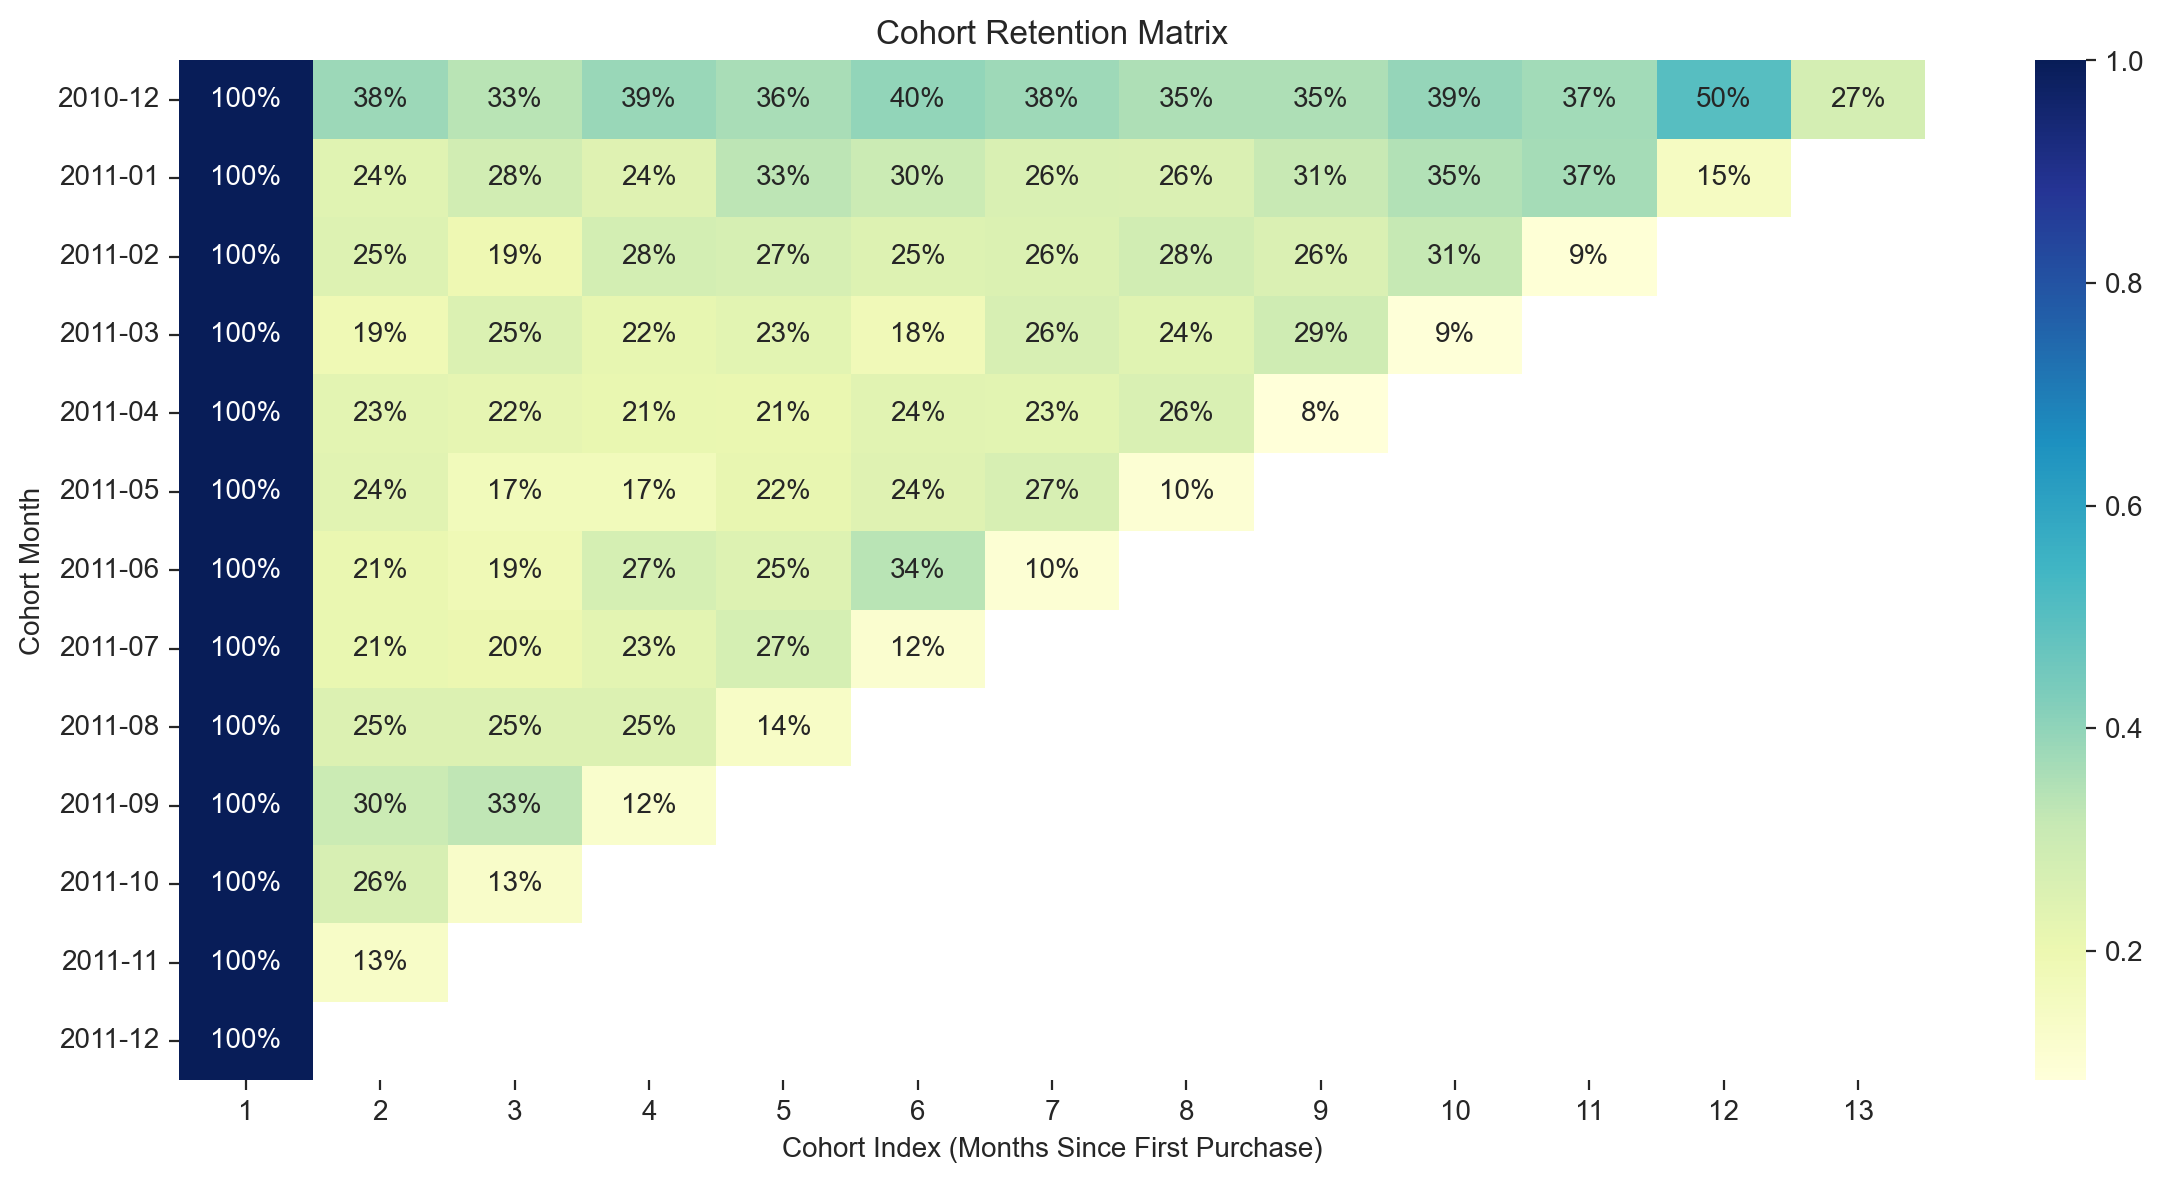

In [120]:
# Visualize with heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(cohort_retention, annot=True, fmt=".0%", cmap="YlGnBu")
plt.title('Cohort Retention Matrix')
plt.xlabel('Cohort Index (Months Since First Purchase)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

### - The cohort retention matrix shows the proportion of customers remaining active over time. 
### - The matrix showed a significant decline in retention from Month 1 to Month 2 across all cohorts. This sharp drop suggests that many customers only made one purchase and did not return, which may highlight issues such as lack of effective post-purchase engagement, limited product variety or perceived value, potential pricing or service-related concerns, weak onboarding or communication strategy. 
### - Despite dropping from 100% in Month 1 to 38% in Month 2, the December 2010 cohort maintained a remarkably consistent retention over time, reaching 50% in Month 12. This could be attributed to seasonal shopping habits such as holiday purchases in December, well-executed promotional campaigns or discounts and elevated customer experience during the festive season. 
### - The matrix reflects a general downward trend in retention as the months progress — with most cohorts struggling to maintain engagement after the first few months. 
### - It is also observed that every cohort tends to underperformed in December 2011.

# Retention Curves

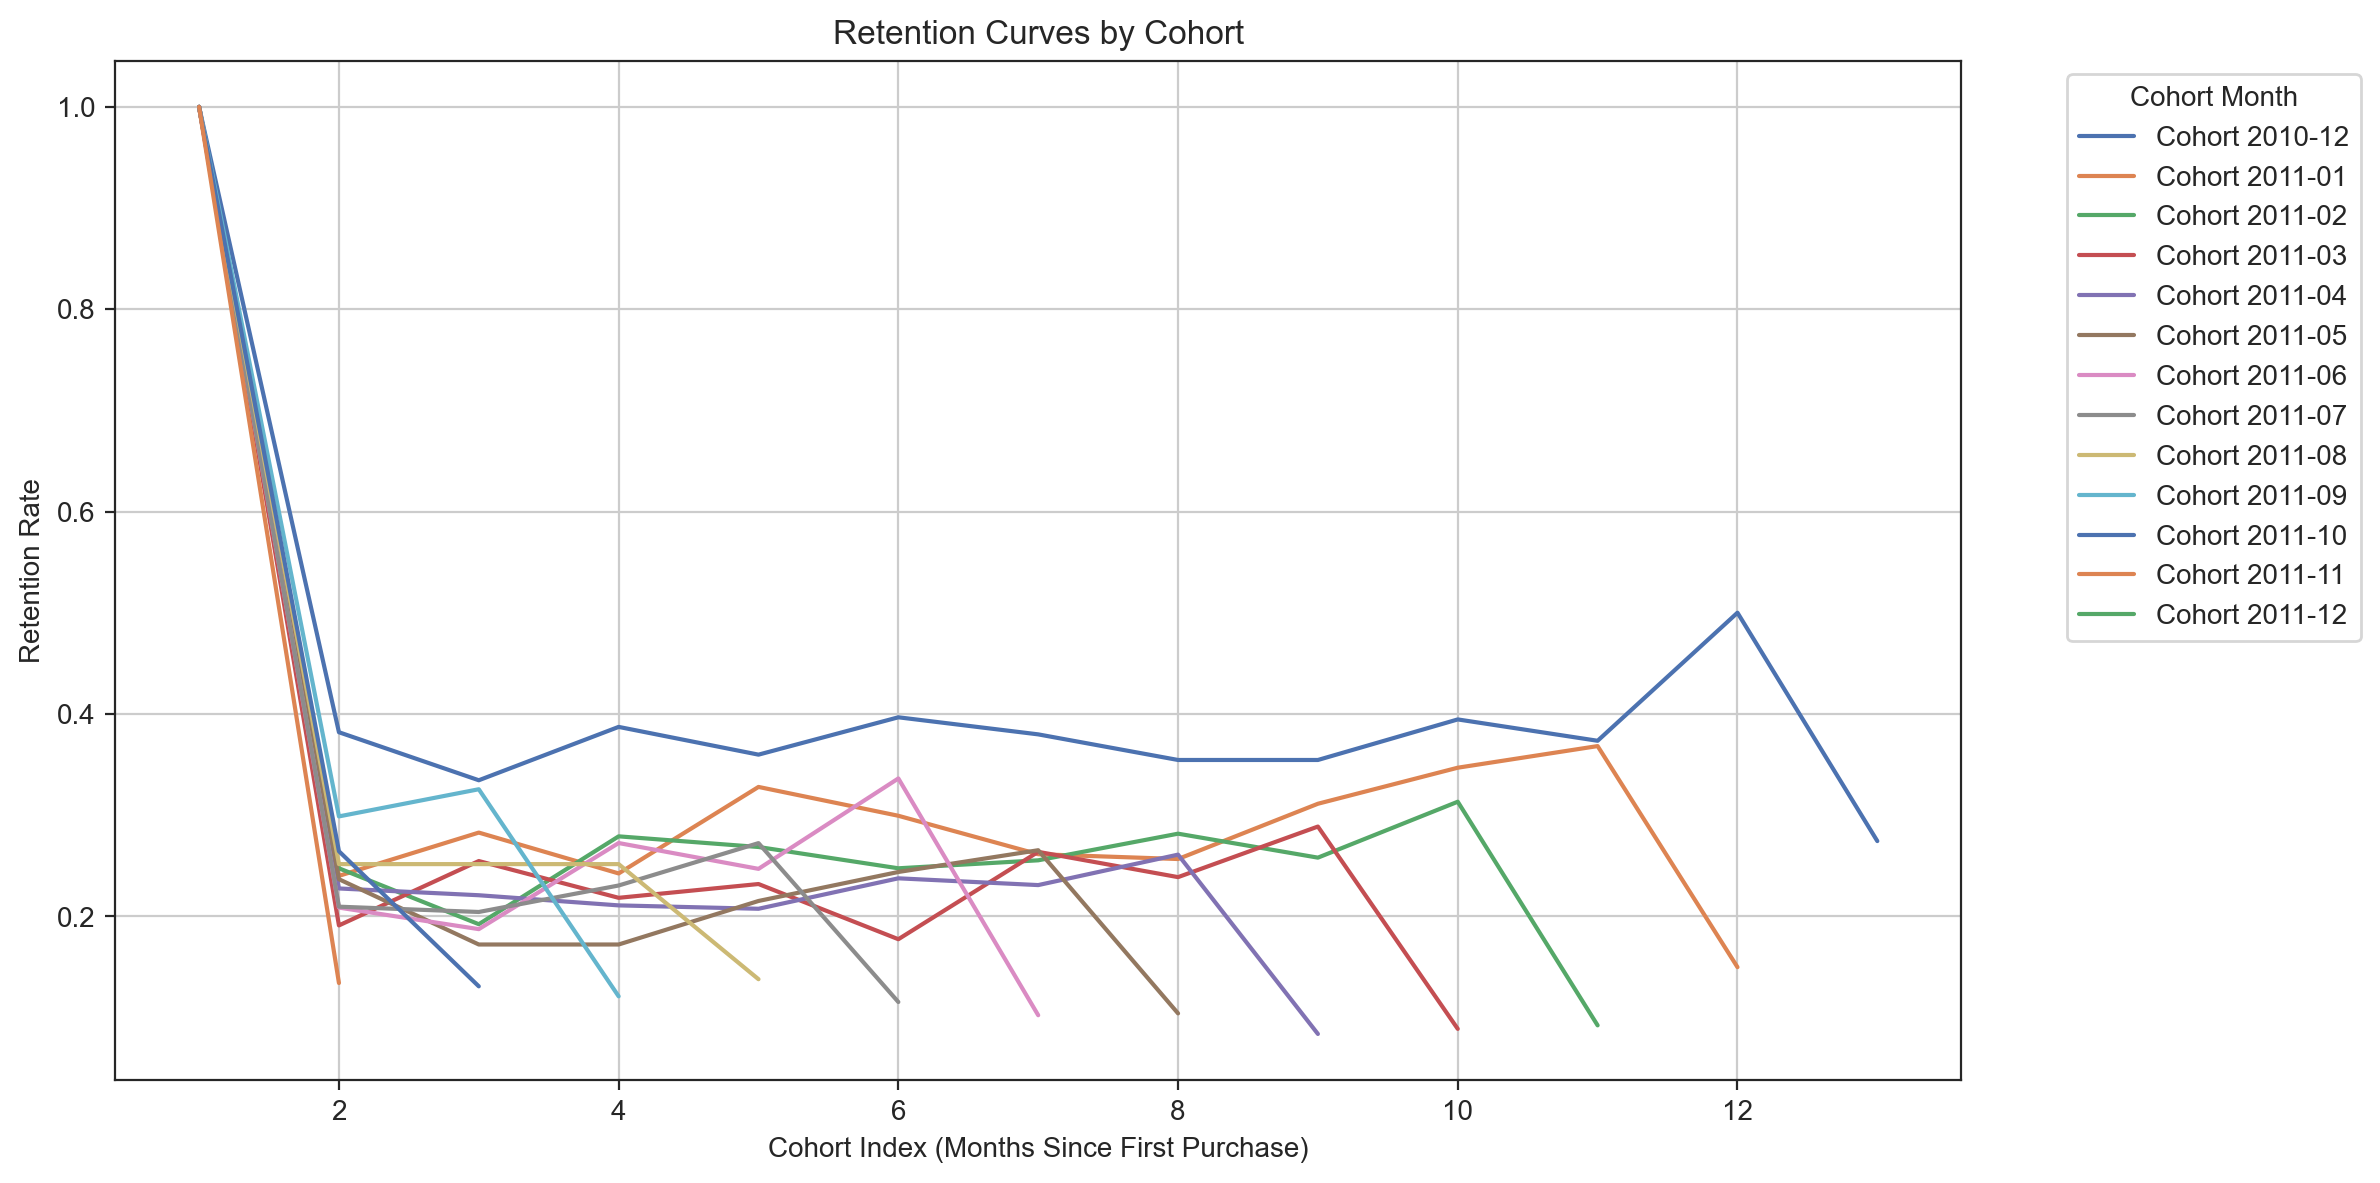

In [124]:
# Plot retention curves for each cohort (using the cohort_retention matrix)
plt.figure(figsize=(12, 6))

# Loop over each cohort (CohortMonth) and plot the retention curve
for cohort in cohort_retention.index:  # Iterate over each cohort
    plt.plot(cohort_retention.columns, cohort_retention.loc[cohort], label=f'Cohort {cohort.strftime("%Y-%m")}')

plt.title("Retention Curves by Cohort")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Retention Rate")
plt.legend(title='Cohort Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [126]:
cohort_data = ecom_data.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

print(cohort_counts.head())

CohortIndex     1      2      3      4      5      6      7      8      9   \
CohortMonth                                                                  
2010-12      948.0  362.0  317.0  367.0  341.0  376.0  360.0  336.0  336.0   
2011-01      421.0  101.0  119.0  102.0  138.0  126.0  110.0  108.0  131.0   
2011-02      380.0   94.0   73.0  106.0  102.0   94.0   97.0  107.0   98.0   
2011-03      440.0   84.0  112.0   96.0  102.0   78.0  116.0  105.0  127.0   
2011-04      299.0   68.0   66.0   63.0   62.0   71.0   69.0   78.0   25.0   

CohortIndex     10     11     12     13  
CohortMonth                              
2010-12      374.0  354.0  474.0  260.0  
2011-01      146.0  155.0   63.0    NaN  
2011-02      119.0   35.0    NaN    NaN  
2011-03       39.0    NaN    NaN    NaN  
2011-04        NaN    NaN    NaN    NaN  


In [128]:
cohort_data.rename(columns = {"CustomerID" : "Number of customers"}, inplace = True)

In [130]:
cohort_data

,CohortMonth,CohortIndex,Number of customers
0,2010-12,1,948
1,2010-12,2,362
2,2010-12,3,317
3,2010-12,4,367
4,2010-12,5,341
...,...,...,...
86,2011-10,2,93
87,2011-10,3,46
88,2011-11,1,321
89,2011-11,2,43


In [132]:
cohort_table = cohort_data.pivot(index = 'CohortMonth', columns =  ['CohortIndex'], values = "Number of customers")

In [134]:
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


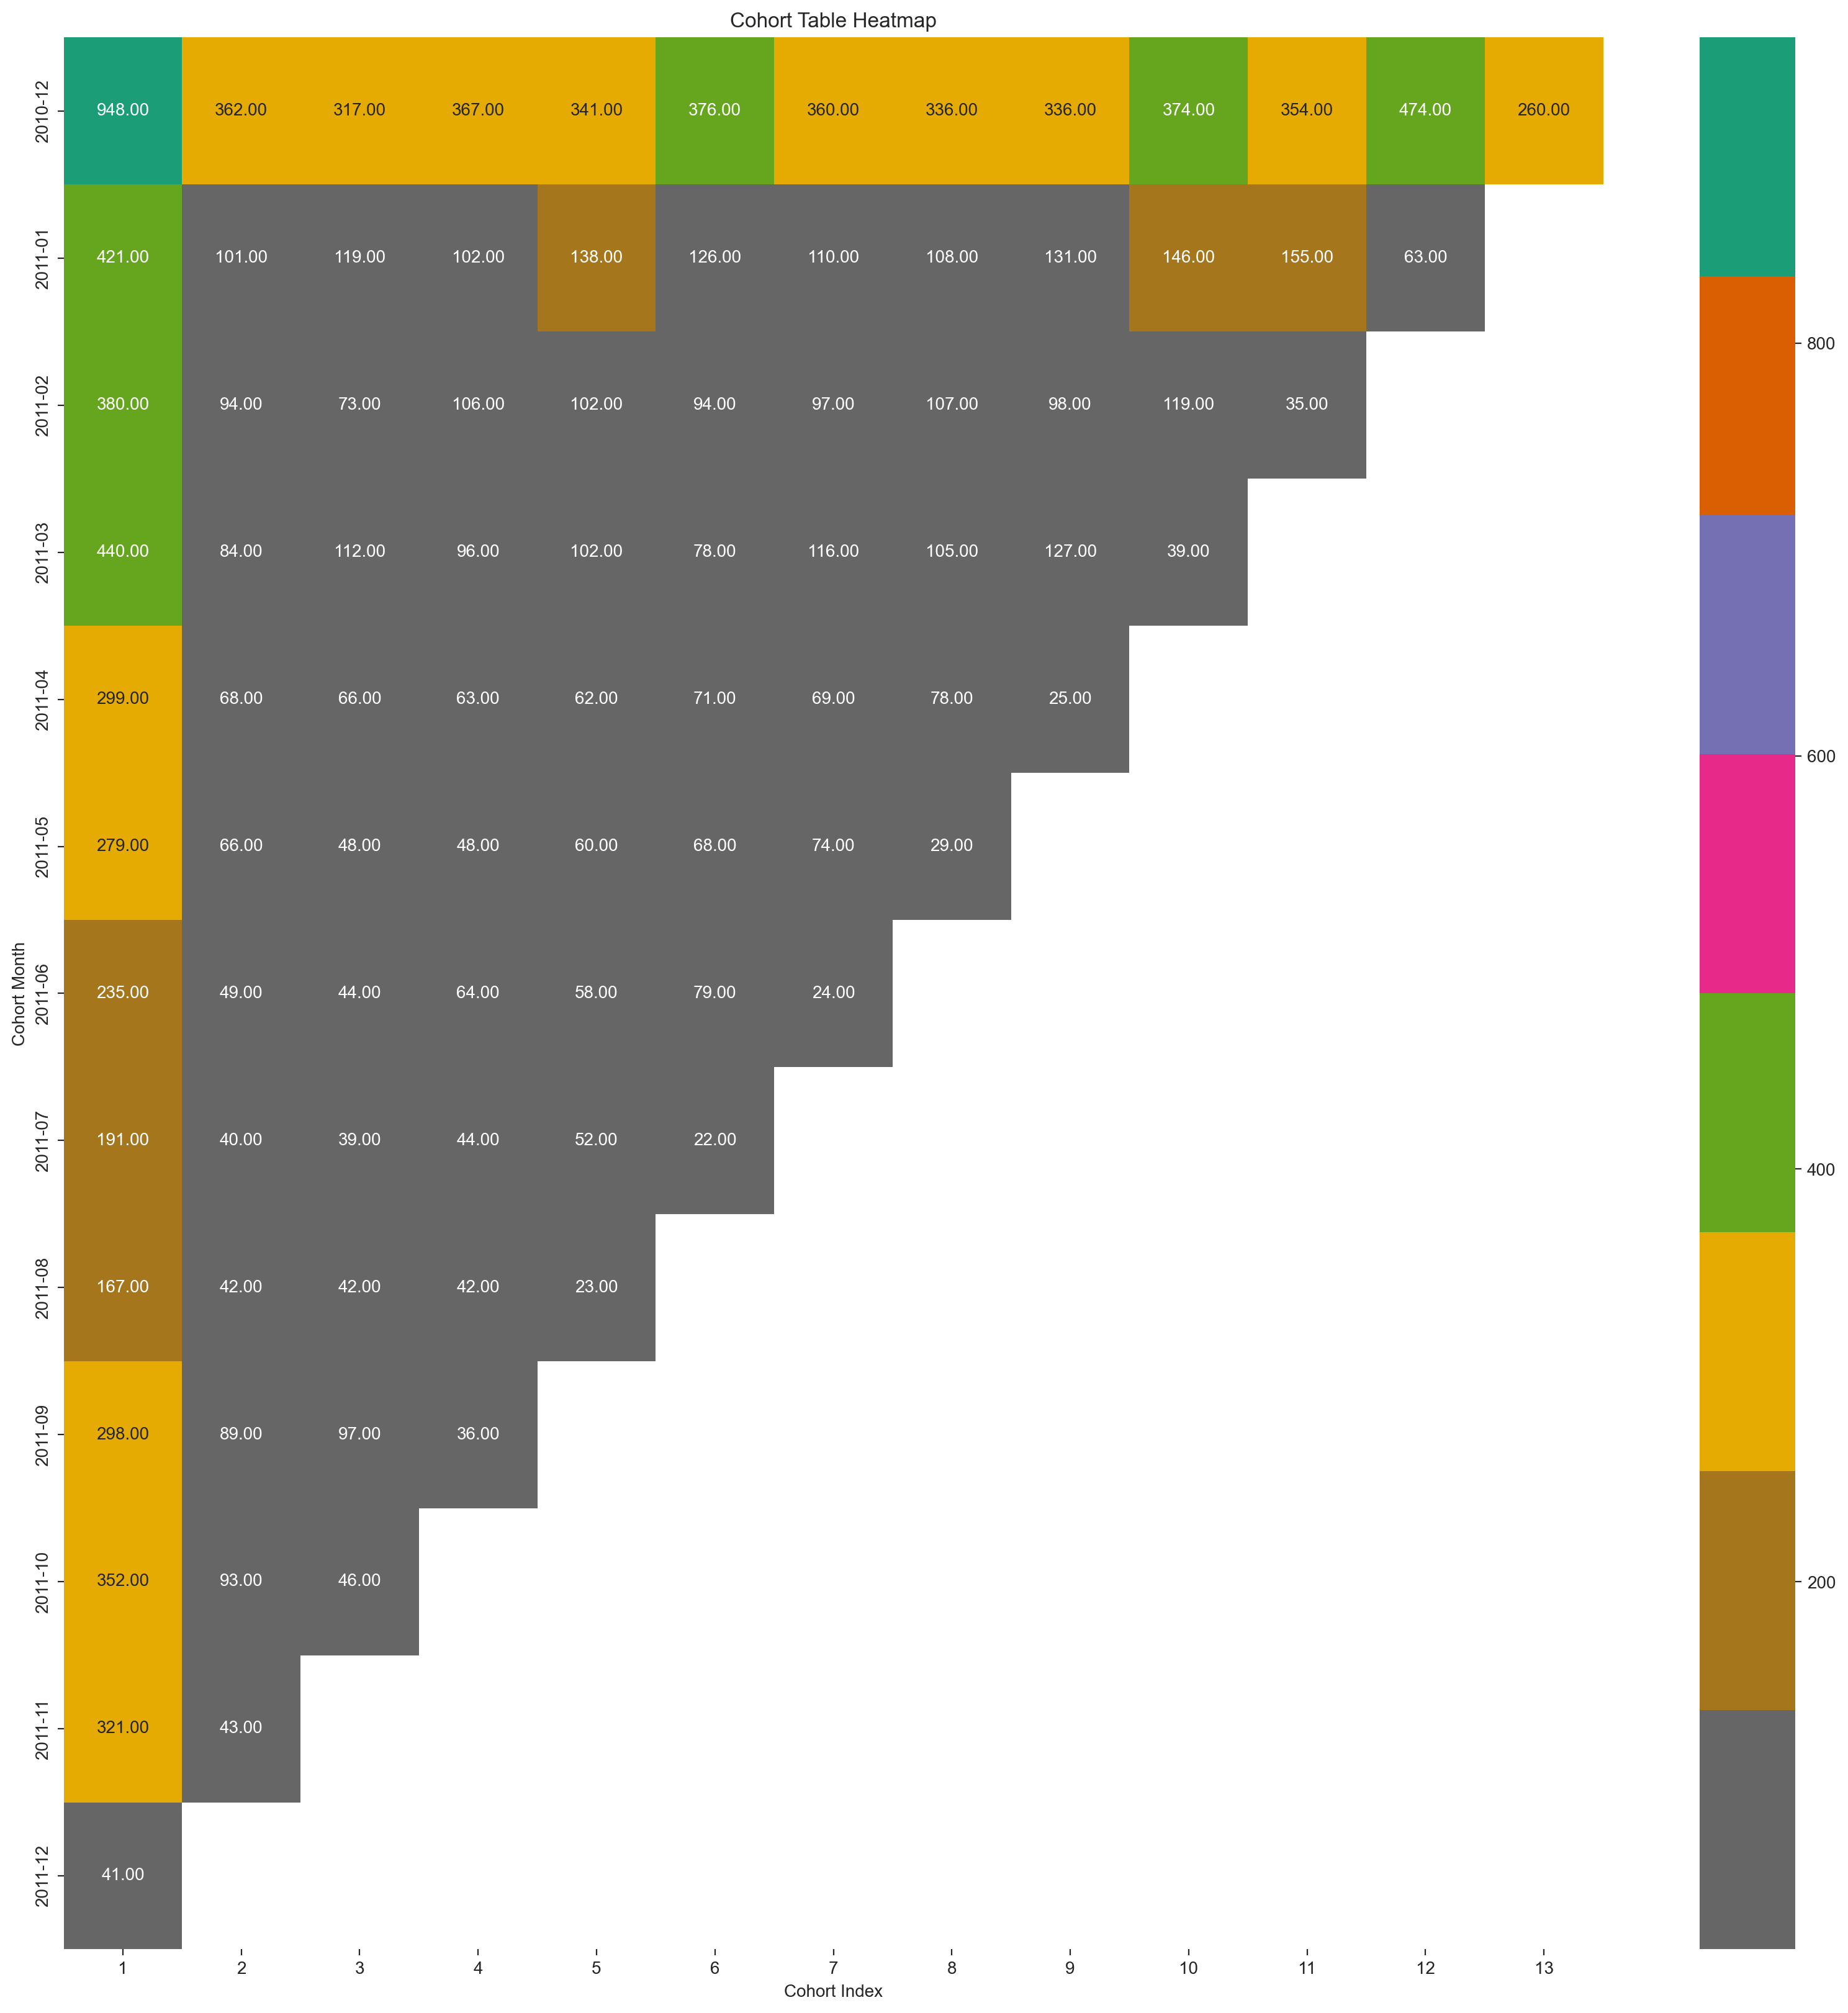

In [136]:
plt.figure(figsize=(20, 20))
sns.heatmap(cohort_table, annot=True, cmap="Dark2_r", fmt = ".2f")
plt.title('Cohort Table Heatmap')
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()

# Churn Timing Analysis

In [139]:
# Define churn threshold (customers are considered churned if retention falls below 30% in a month)
churn_threshold = 0.3

In [141]:
# Calculate churn month for each cohort
churn_timing = []

for cohort in cohort_retention.index:
    # Get the retention rates for the cohort
    retention_values = cohort_retention.loc[cohort].values
    
    # Find the first month where retention is below the threshold (churn month)
    churn_month = np.argmax(retention_values < churn_threshold) + 1  # Adding 1 to match CohortIndex
    if retention_values[0] >= churn_threshold:  # Only consider customers who don't churn immediately
        churn_timing.append(churn_month)

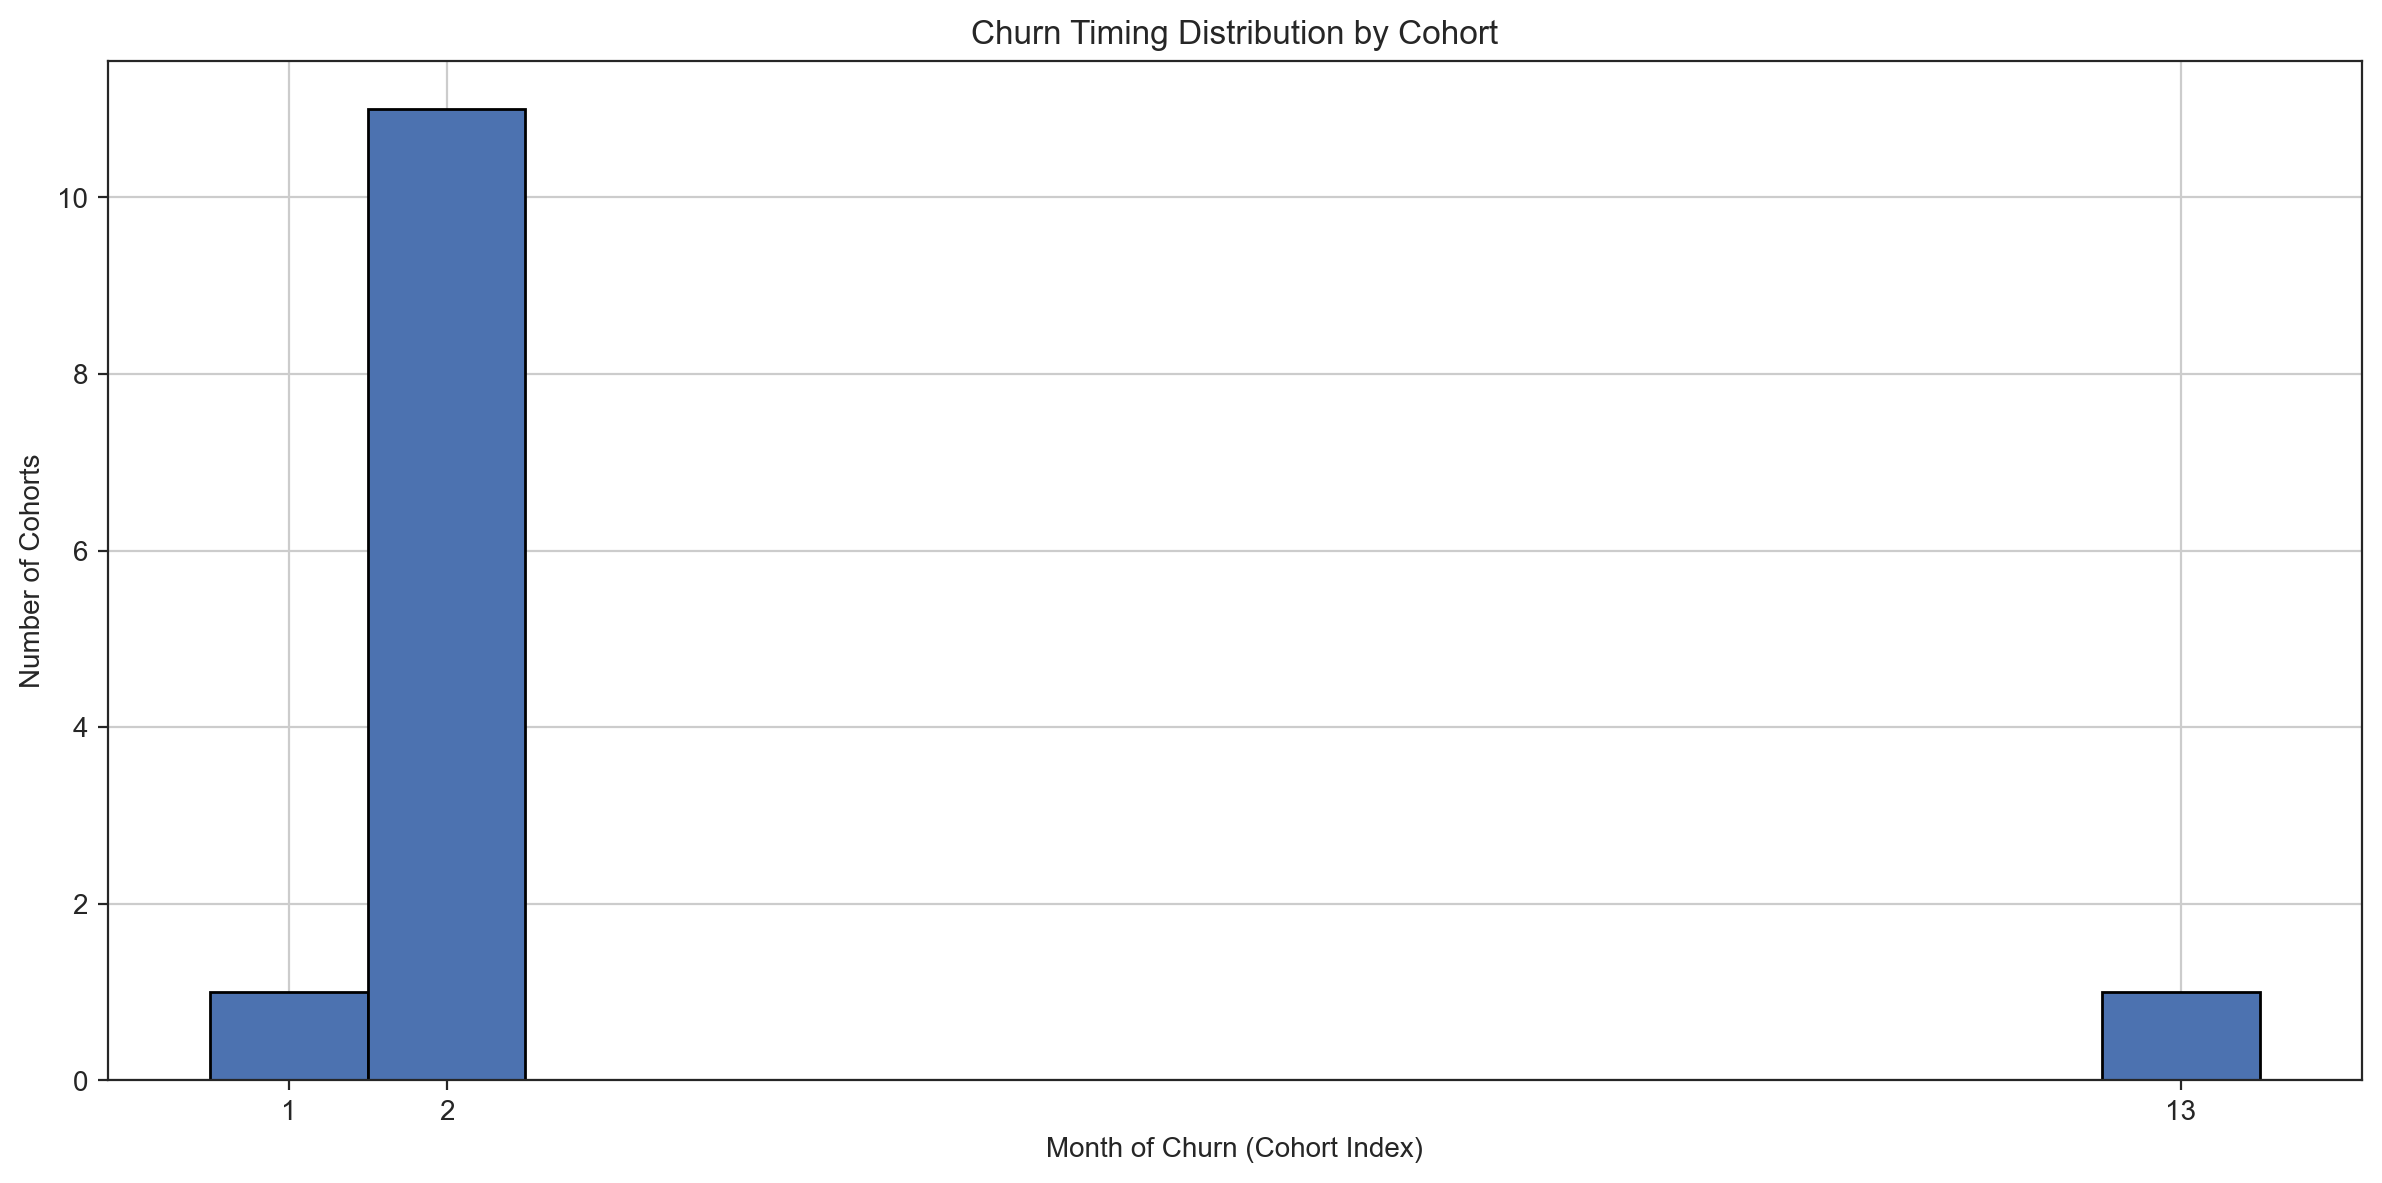

In [143]:
# Churn timing analysis: Count the frequency of churn in each month across cohorts
churn_counts = pd.Series(churn_timing).dropna().astype(int)

# Plot churn timing distribution (when customers are most likely to churn)
plt.clf()
plt.close('all')  # Clear any previous figures that might cause ghost/empty plots

plt.figure(figsize=(12, 6))
plt.hist(churn_counts, bins=range(1, churn_counts.max() + 2), edgecolor="black", align="left")
plt.title("Churn Timing Distribution by Cohort")
plt.xlabel("Month of Churn (Cohort Index)")
plt.ylabel("Number of Cohorts")
plt.xticks(sorted(churn_counts.unique()))  # Modified line: dynamic ticks based on actual values
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation - The histogram of churn timing distribution by cohort showed that majority of customers tend to churn in Month 2. This shows that the risk of losing customers is highest Month 2.

# Defining Churn Logic

In [147]:
# Define churn logic based on 3 months of inactivity
# Get last purchase date per customer
last_purchase = ecom_data.groupby('CustomerID')['InvoiceDate'].max()

cutoff_date = ecom_data['InvoiceDate'].max() - pd.DateOffset(months=3)
churn_flag = last_purchase < cutoff_date

# Combine into customer profile
customer_churn_df = pd.DataFrame({
    'LastPurchase': last_purchase,
    'IsChurned': churn_flag
})

print(customer_churn_df.head())

                  LastPurchase  IsChurned
CustomerID                               
12346      2011-01-18 10:17:00       True
12347      2011-12-07 15:52:00      False
12348      2011-09-25 13:13:00      False
12349      2011-11-21 09:51:00      False
12350      2011-02-02 16:01:00       True


In [149]:
print(customer_churn_df['IsChurned'].value_counts())

IsChurned
False    2922
True     1450
Name: count, dtype: int64


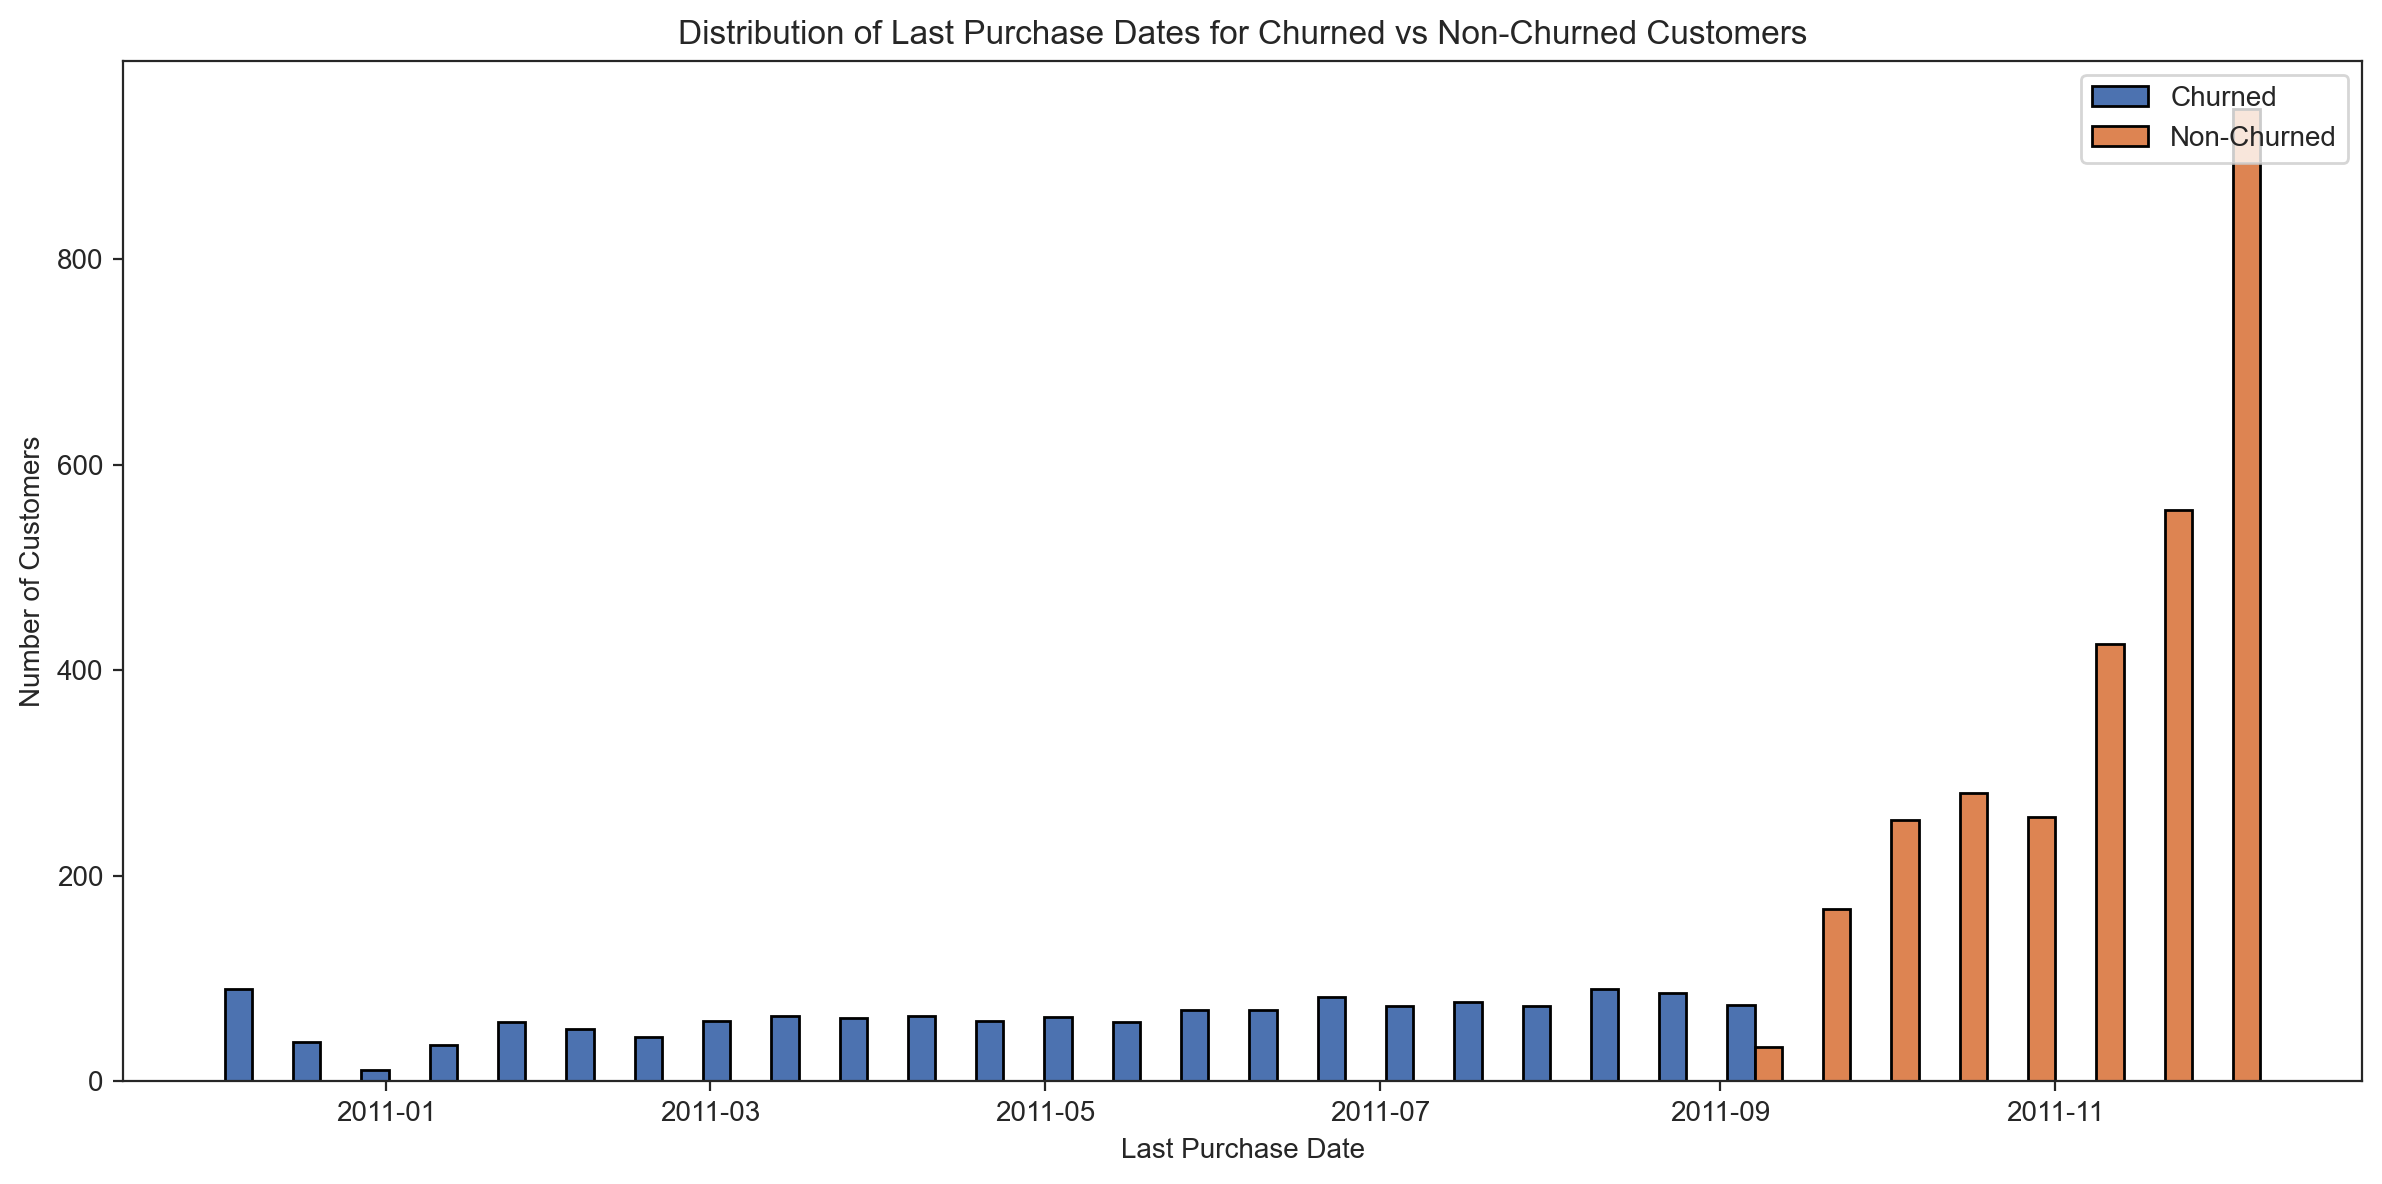

In [151]:
# Plot churn vs non-churned customers for diagnostic purposes
plt.figure(figsize=(12, 6))
churned_customers = customer_churn_df[customer_churn_df['IsChurned'] == True]
non_churned_customers = customer_churn_df[customer_churn_df['IsChurned'] == False]

# Plot churned and non-churned distributions
plt.hist([churned_customers['LastPurchase'], non_churned_customers['LastPurchase']], bins=30, edgecolor='black', label=['Churned', 'Non-Churned'])
plt.legend(loc='upper right')
plt.title('Distribution of Last Purchase Dates for Churned vs Non-Churned Customers')
plt.xlabel('Last Purchase Date')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

# Explore Reasons For Churn

In [154]:
# Define churned and non-churned customers' IDs
churned_customers_ids = customer_churn_df[customer_churn_df['IsChurned'] == True].index
non_churned_customers_ids = customer_churn_df[customer_churn_df['IsChurned'] == False].index

In [156]:
# Filter ecom_data to separate churned and non-churned customers
churned_customers = ecom_data[ecom_data['CustomerID'].isin(churned_customers_ids)]
non_churned_customers = ecom_data[~ecom_data['CustomerID'].isin(churned_customers_ids)]

In [158]:
# Analyze the distribution of product categories (Description) between churned and non-churned customers
churned_categories = churned_customers['Description'].value_counts()
non_churned_categories = non_churned_customers['Description'].value_counts()

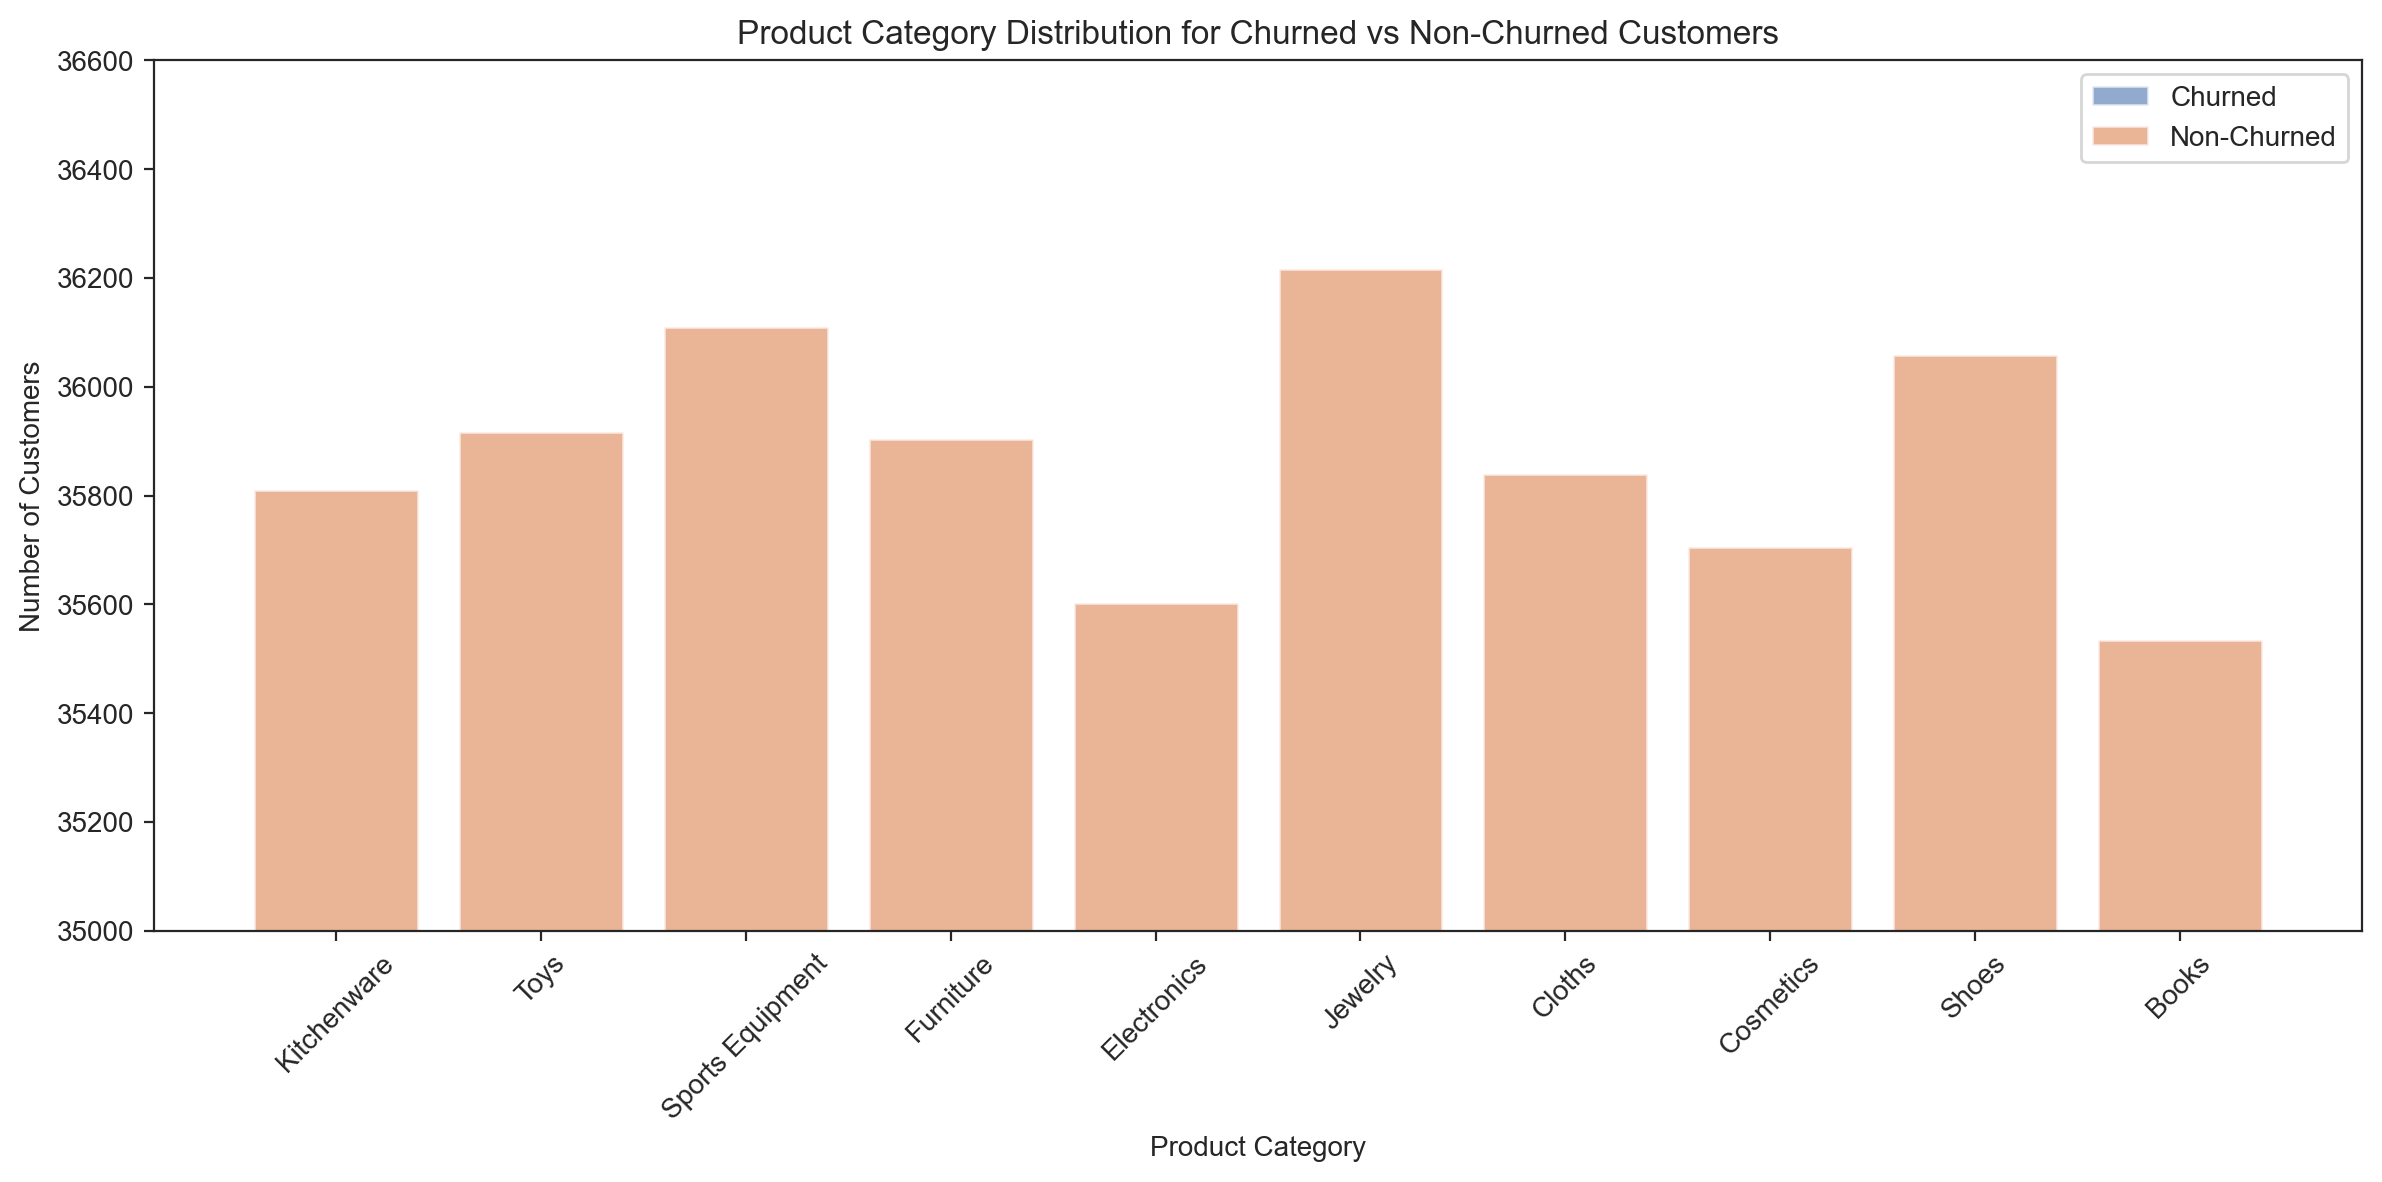

In [164]:
# Visualize the churned vs non-churned product category distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(churned_categories.index, churned_categories.values, alpha=0.6, label='Churned')
plt.bar(non_churned_categories.index, non_churned_categories.values, alpha=0.6, label='Non-Churned')
plt.title("Product Category Distribution for Churned vs Non-Churned Customers")
plt.xlabel("Product Category")
plt.ylabel("Number of Customers")
plt.ylim(3.50e4, 3.66e4)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

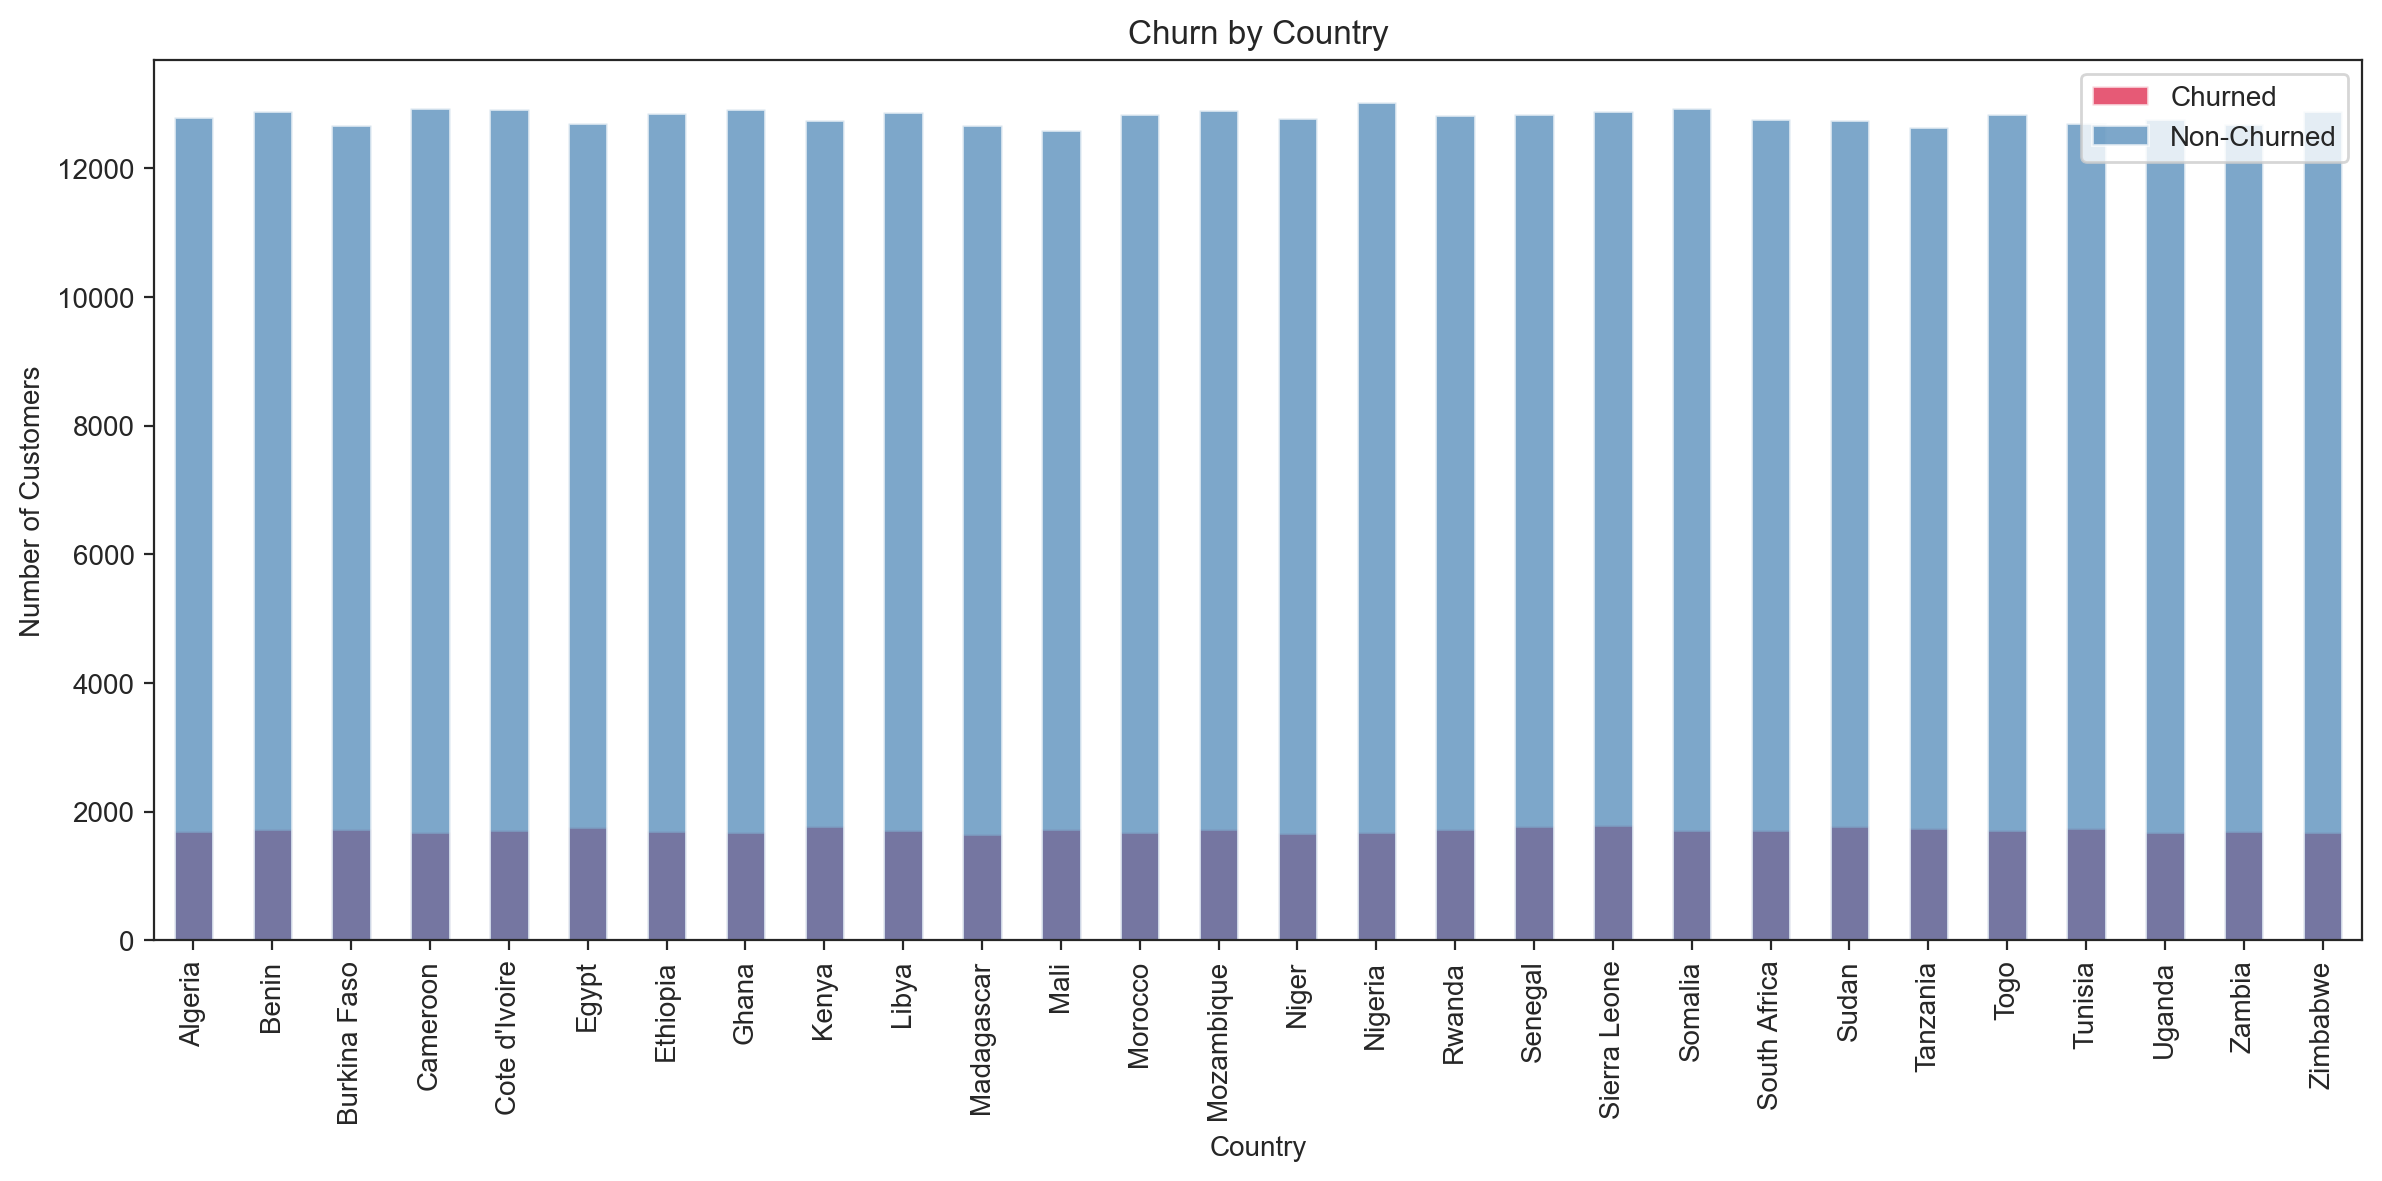

In [168]:
# Identify the Countries in which customer are more likely to churn.
churned_demographics = churned_customers.groupby('Country')['CustomerID'].count()
non_churned_demographics = non_churned_customers.groupby('Country')['CustomerID'].count()

# Align the index to avoid mismatch between plots
combined_index = churned_demographics.index.union(non_churned_demographics.index)
churned_demographics = churned_demographics.reindex(combined_index, fill_value=0)
non_churned_demographics = non_churned_demographics.reindex(combined_index, fill_value=0)

# Plot churn by country with distinct colors
plt.figure(figsize=(12, 6))
churned_demographics.plot(kind='bar', color='crimson', alpha=0.7, label='Churned')
non_churned_demographics.plot(kind='bar', color='steelblue', alpha=0.7, label='Non-Churned')

plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Number of Customers')

plt.legend()
plt.tight_layout()
plt.show()

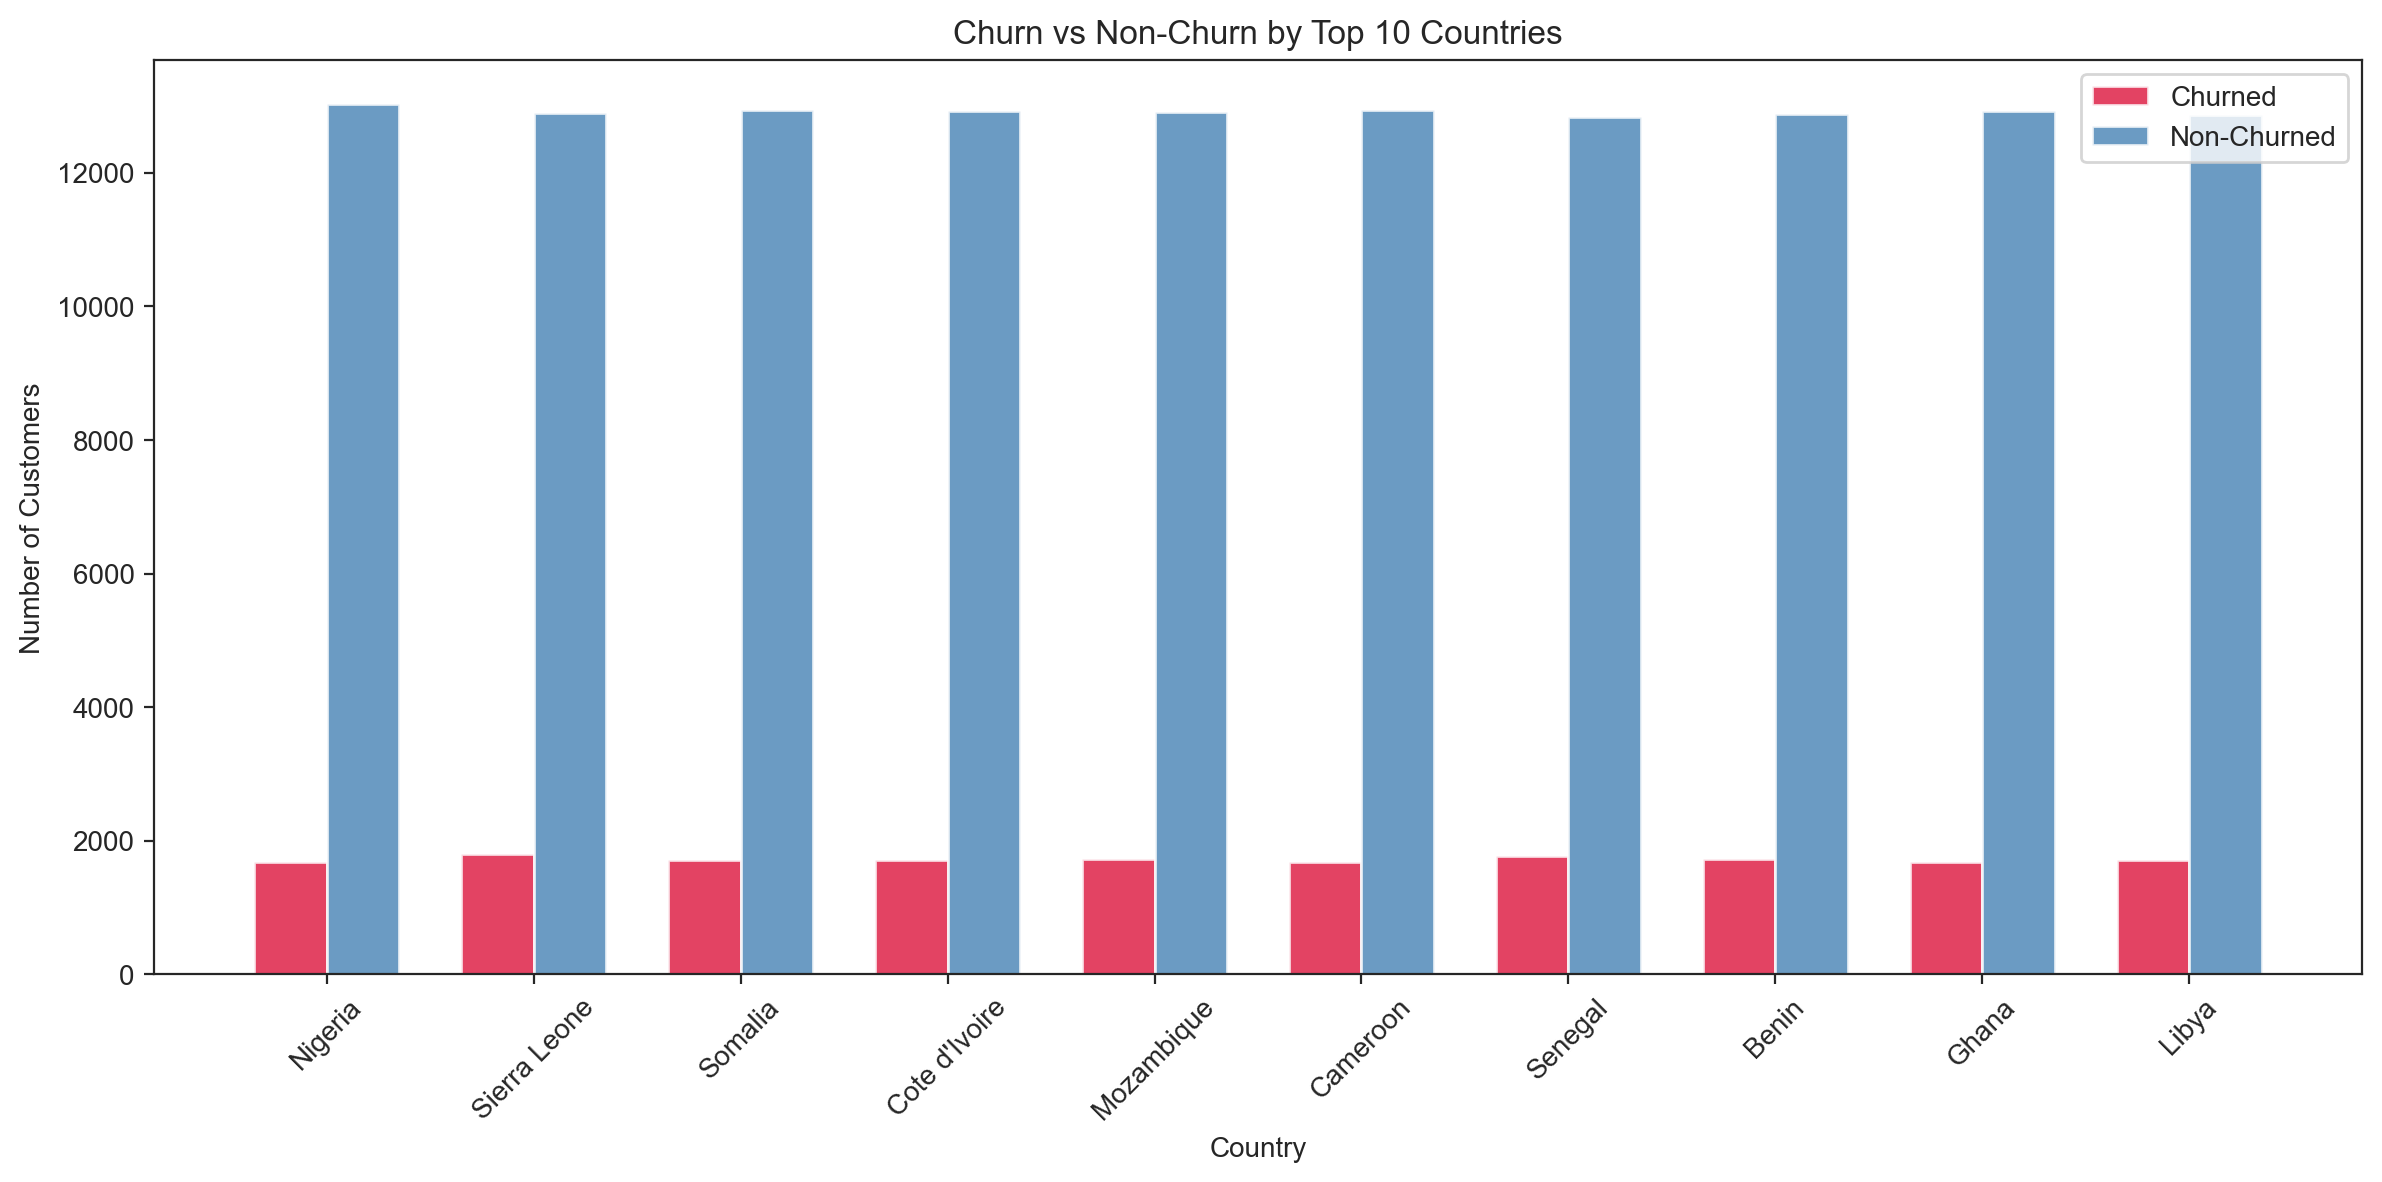

In [176]:
# Group and count customers per country
churned_demographics = churned_customers.groupby('Country')['CustomerID'].count()
non_churned_demographics = non_churned_customers.groupby('Country')['CustomerID'].count()

# Combine and sum for total customers per country
total_customers = churned_demographics.add(non_churned_demographics, fill_value=0)

# Select top 10 countries with the most customers
top_10_countries = total_customers.sort_values(ascending=False).head(10).index

# Filter both churned and non-churned to only top 10 countries
churned_top10 = churned_demographics.reindex(top_10_countries, fill_value=0)
non_churned_top10 = non_churned_demographics.reindex(top_10_countries, fill_value=0)

# Plot side-by-side bar chart
import numpy as np
x = np.arange(len(top_10_countries))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, churned_top10, width, label='Churned', color='crimson', alpha=0.8)
plt.bar(x + width/2, non_churned_top10, width, label='Non-Churned', color='steelblue', alpha=0.8)

plt.xticks(x, top_10_countries, rotation=45)
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.title('Churn vs Non-Churn by Top 10 Countries')
plt.legend()
plt.tight_layout()
plt.show()

### The number of customers churned by Country were smaller compared to non churned across the Top 10 Countries

# Customer Lifetime Value (CLV) Modeling Stage

In [154]:
!pip install lifetimes

In [156]:
# Get FirstPurchaseDate
first_purchase = ecom_data.groupby('CustomerID')['InvoiceDate'].min()

# Compute T = time since first purchase
rfm['T'] = (reference_date - first_purchase).dt.days

In [158]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'T'], dtype='object')


## Train the BG/NBD Model

In [161]:
from lifetimes import BetaGeoFitter

# Initialize the model
bgf = BetaGeoFitter()

# Fit the model
bgf.fit(frequency=rfm['Frequency'], recency=rfm['Recency'], T=rfm['T'])

<lifetimes.BetaGeoFitter: fitted with 4372 subjects, a: 8.86, alpha: 1.32, b: 60.07, r: 0.37>

### The parameters suggest a relatively low purchase frequency rate (r is small), Customers become inactive fairly quickly (b is much higher than a), which means churn is a bit high. There's heterogeneity in both purchase and dropout rates.

## Visual Diagnostics of the BG/NBD Model

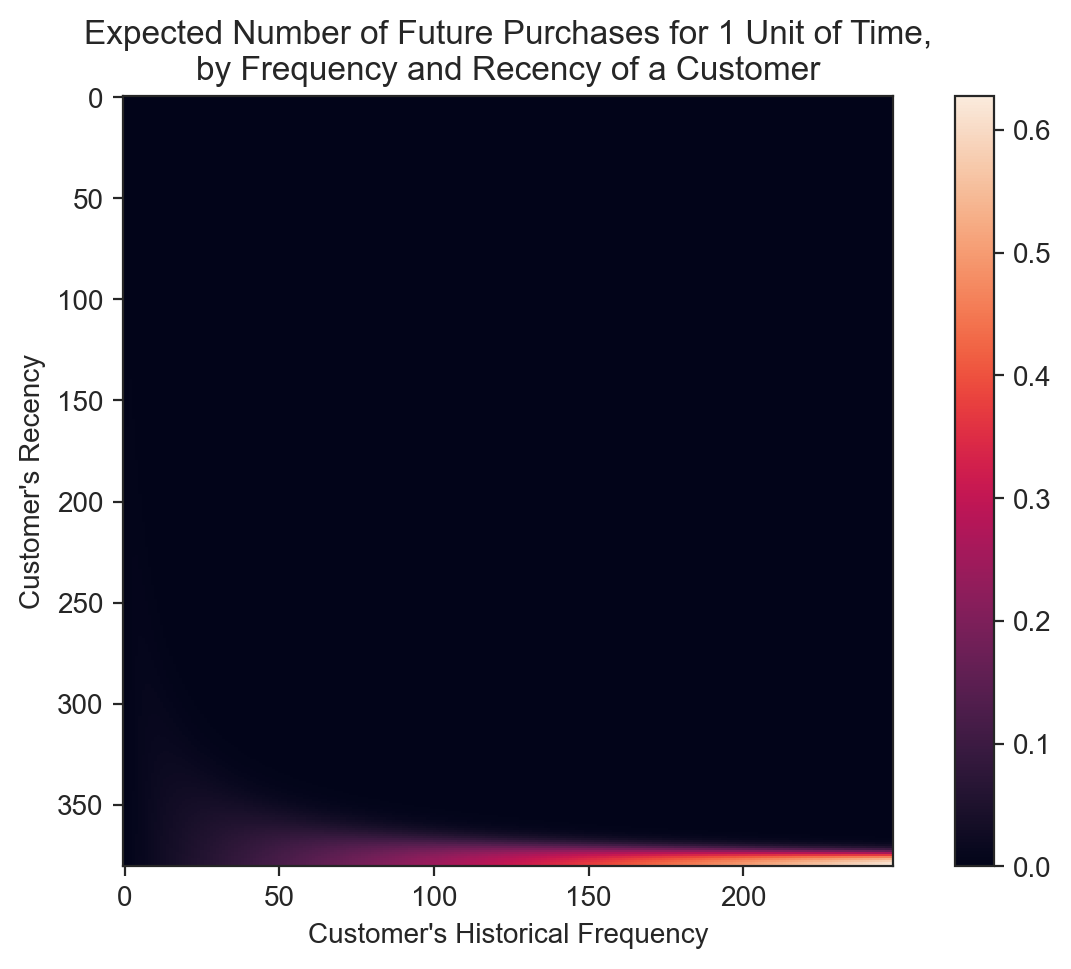

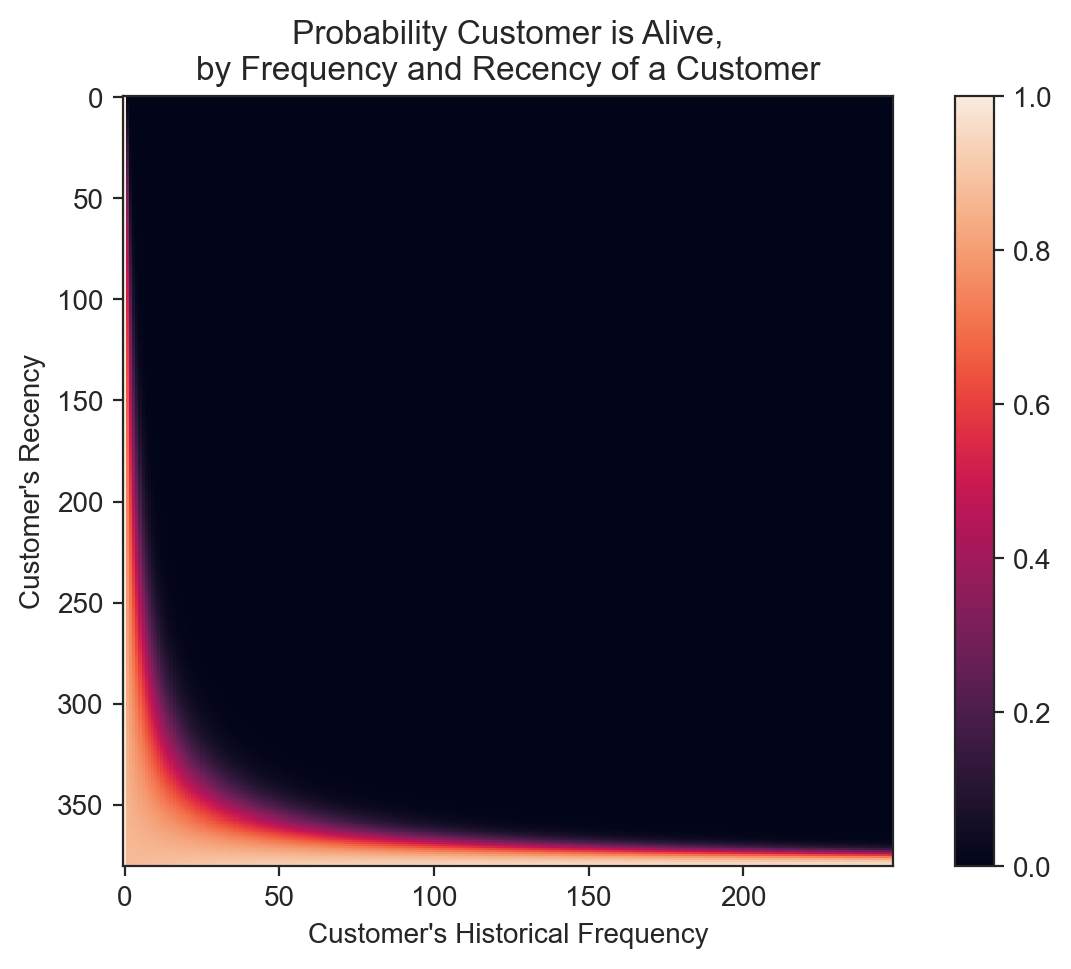

In [165]:
# Plot model diagnostics
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix

plot_frequency_recency_matrix(bgf)
plt.show()

plot_probability_alive_matrix(bgf)
plt.show()

## Predict Expected Purchases

In [167]:
# Future purchases in 90 days for each customer
rfm['predicted_purchases_90d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    rfm['Frequency'],
    rfm['Recency'],
    rfm['T']
)

## Estimate Average Spend per Transaction 

In [169]:
from lifetimes import GammaGammaFitter

# Only keep customers with positive monetary value
rfm_monetary = rfm[rfm['Monetary'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm_monetary['Frequency'], rfm_monetary['Monetary'])

# Predict average transaction value
rfm_monetary['predicted_monetary'] = ggf.conditional_expected_average_profit(
    rfm_monetary['Frequency'],
    rfm_monetary['Monetary']
)

In [170]:
# Create the holdout set (only for validation)
cutoff_date = '2011-09-01'
holdout_df = ecom_data[ecom_data['InvoiceDate'] >= cutoff_date]

# Compute actual 90-day spend per customer from holdout
actual_spend = holdout_df.groupby('CustomerID').apply(
    lambda x: (x['Quantity'] * x['UnitPrice']).sum()
).reset_index(name='actual_spend_90d')

## Compute Predicted CLV

In [172]:
# Predicted 90-day CLV
rfm_monetary['predicted_clv_90d'] = rfm_monetary['predicted_purchases_90d'] * rfm_monetary['predicted_monetary']

In [178]:
# Merge with predicted CLV
clv_eval = rfm_monetary.merge(actual_spend, on='CustomerID', how='inner')

In [180]:
print(clv_eval.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary', 'T',
       'predicted_purchases_90d', 'predicted_monetary', 'predicted_clv_90d',
       'actual_spend_90d'],
      dtype='object')


## Evaluate Predictions with Actual Spend

In [183]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate RMSE and R² score
rmse = mean_squared_error(clv_eval['actual_spend_90d'], clv_eval['predicted_clv_90d'])**0.5
r2 = r2_score(clv_eval['actual_spend_90d'], clv_eval['predicted_clv_90d'])

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 447757.08
R² Score: -0.34


In [185]:
# Calculate RMSE manually
mse = mean_squared_error(clv_eval['actual_spend_90d'], clv_eval['predicted_clv_90d'])
rmse = np.sqrt(mse)

r2 = r2_score(clv_eval['actual_spend_90d'], clv_eval['predicted_clv_90d'])

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 447757.08
R² Score: -0.34


### A higher RMSE indicates that there is a substantial difference between the predicted and actual values, which suggests that your model is not performing well. This value represents the average magnitude of error in your predictions, with larger errors contributing more heavily to the final value. R² values range from 0 to 1, where 1 indicates perfect predictions and 0 indicates that the model does not explain the variability of the target variable. 
### Negative R² values indicate that the model performs worse than a simple mean model (predicting the average of the target variable for all observations). A negative R² value suggests that your model is underfitting or might need more tuning or features to improve its performance. 

## Visualization

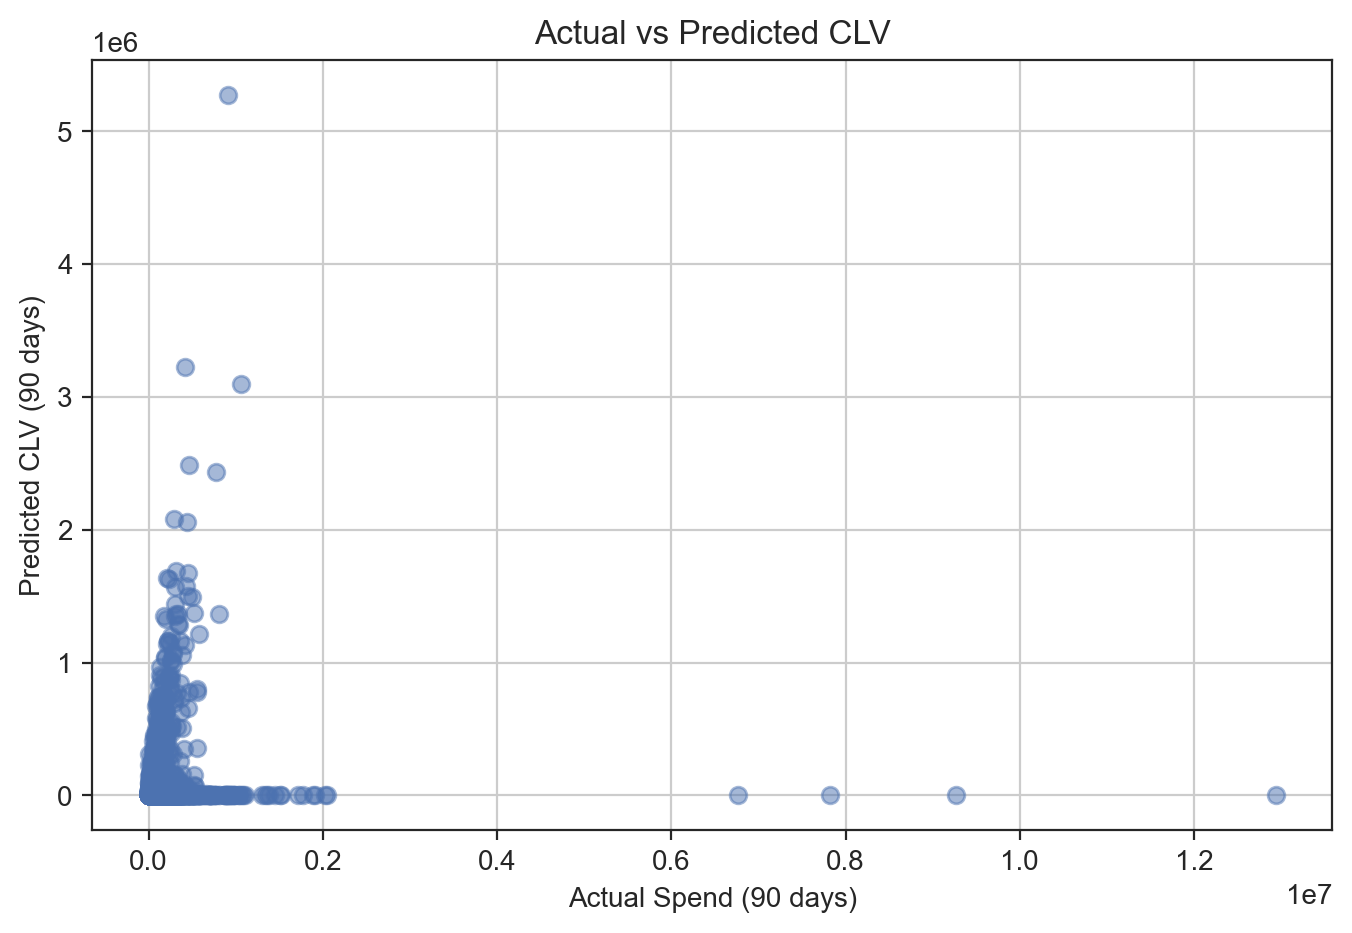

In [189]:
import matplotlib.pyplot as plt

plt.scatter(clv_eval['actual_spend_90d'], clv_eval['predicted_clv_90d'], alpha=0.5)
plt.xlabel('Actual Spend (90 days)')
plt.ylabel('Predicted CLV (90 days)')
plt.title('Actual vs Predicted CLV')
plt.grid(True)
plt.show()

# Building classification models and customer segments based on behavior

In [192]:
# Choose a cutoff date to define churn (e.g., 90 days before the latest date)
cutoff_date = ecom_data['InvoiceDate'].max() - pd.Timedelta(days=90)

# Get last purchase date for each customer
customer_last_purchase = ecom_data.groupby('CustomerID')['InvoiceDate'].max().reset_index()
customer_last_purchase.rename(columns={'InvoiceDate': 'LastPurchase'}, inplace=True)

# Label churned customers (True if they haven't purchased since the cutoff)
customer_last_purchase['IsChurned'] = customer_last_purchase['LastPurchase'] < cutoff_date

# Now you have a clean churn label dataframe
customer_churn_df = customer_last_purchase

In [194]:
clv_eval = clv_eval.merge(customer_churn_df[['CustomerID', 'IsChurned']], on='CustomerID', how='left')

In [196]:
# Select relevant features and target
features = ['Recency', 'Frequency', 'Monetary', 'predicted_purchases_90d', 'predicted_monetary', 'predicted_clv_90d']
X = clv_eval[features]
y = clv_eval['IsChurned']

In [198]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training a Random Forest Classifier

In [201]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_predictions))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print("Random Forest Accuracy Score:", accuracy_score(y_test, rf_predictions))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_predictions))

Random Forest Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Random Forest Confusion Matrix:
[[588   0]
 [  0  12]]
Random Forest Accuracy Score: 1.0
Random Forest ROC-AUC: 1.0


### Of the 872 test samples, 588 are non-churned (False), and 12 are churned (True)

## Hyperparameter Tuning

In [205]:
# Perform cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())

Cross-validation scores: [1.         1.         0.99833055 1.         1.        ]
Mean cross-validation score: 0.9996661101836395


In [207]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}

random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, n_iter=50, cv=5)
random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)

Best parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 16, 'n_estimators': 165}


In [209]:
best_rf_model = random_search.best_estimator_

# Evaluate the Test Set

In [212]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Predict
y_pred = best_rf_model.predict(X_test)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1]))

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Confusion Matrix:
[[588   0]
 [  0  12]]
Accuracy: 1.0
ROC-AUC Score: 1.0


## Visualize Feature Importance

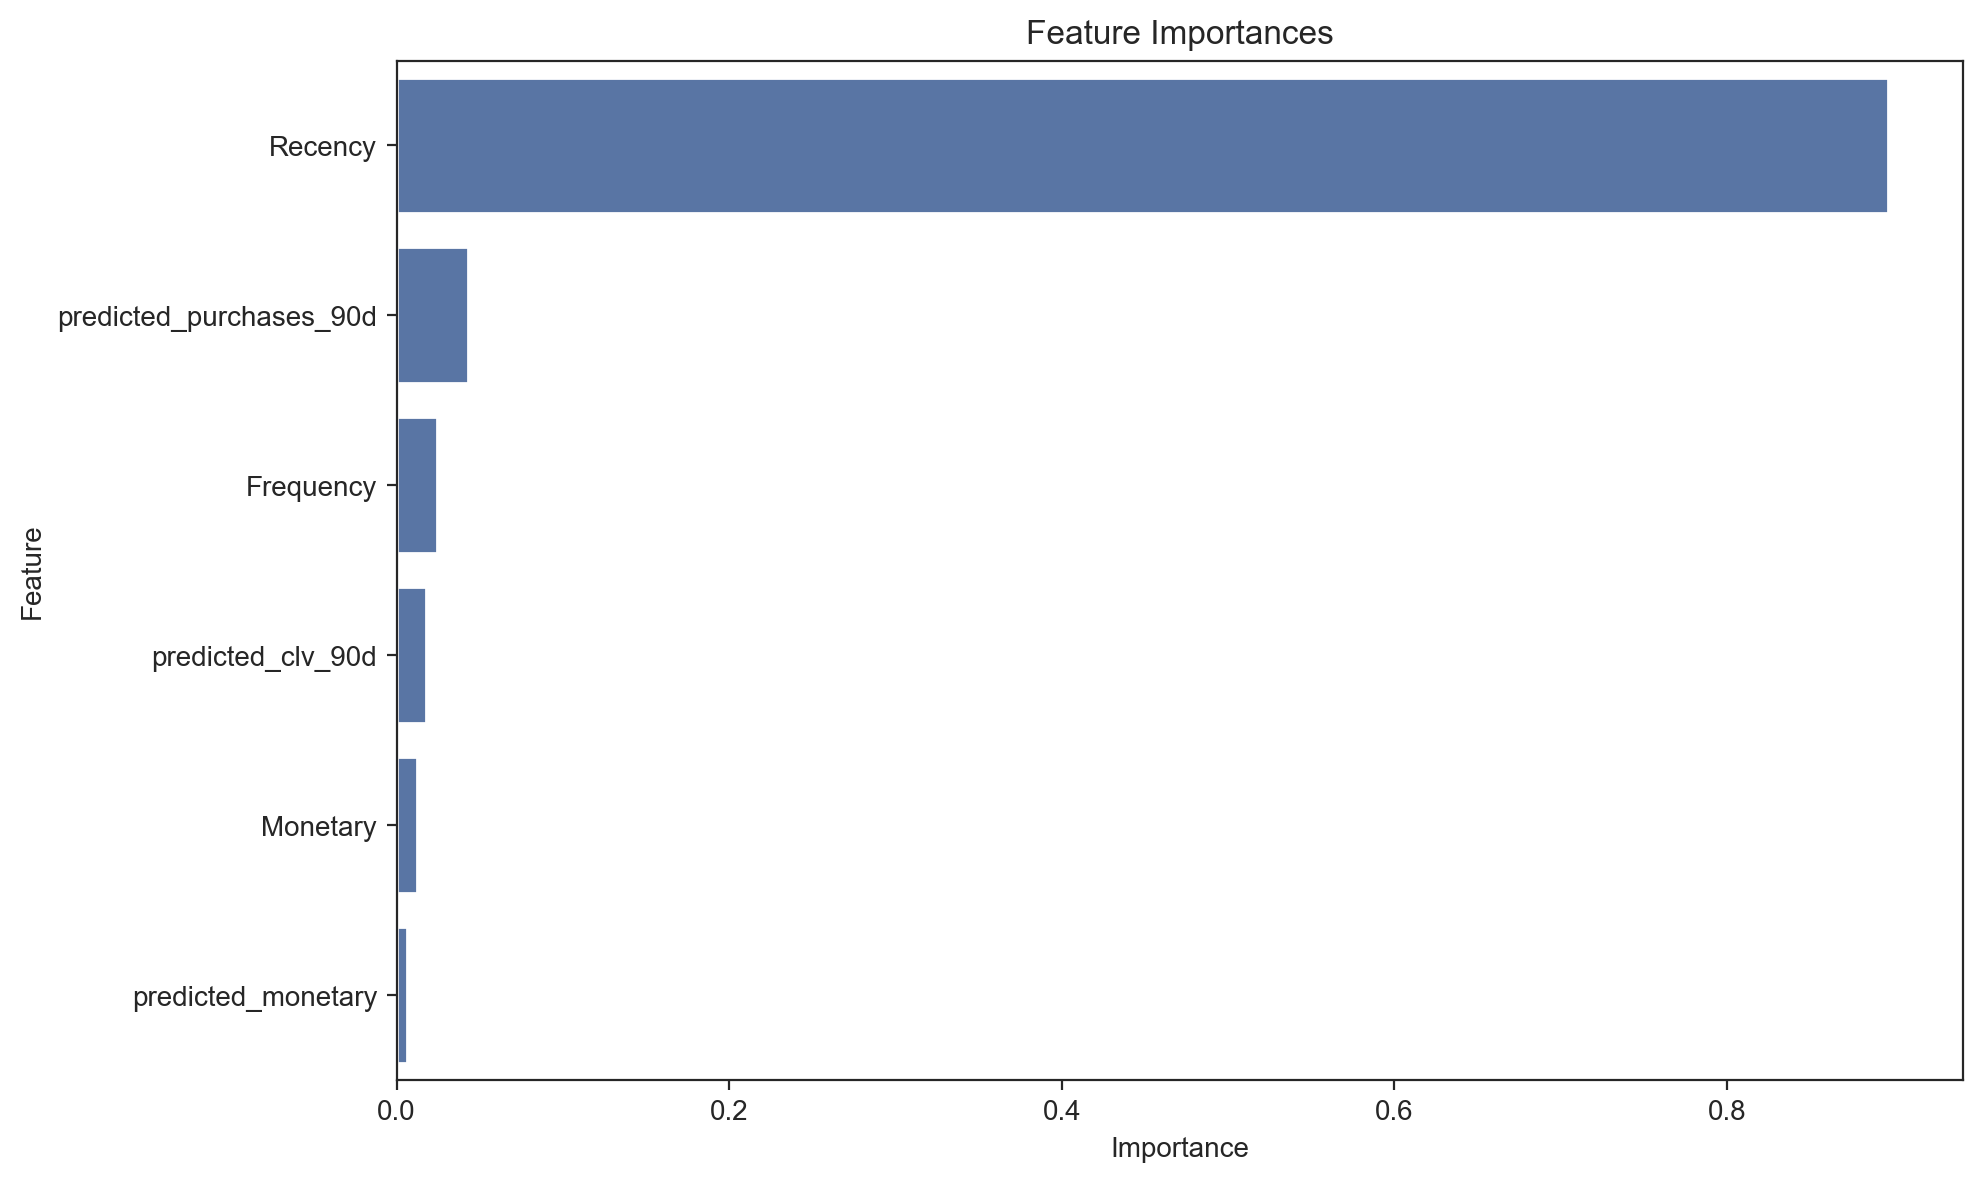

In [215]:
feature_importances = pd.Series(best_rf_model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [217]:
import joblib

# Save the best model after hyperparameter tuning
joblib.dump(random_search.best_estimator_, 'best_random_forest_model.pkl')

['best_random_forest_model.pkl']

# Training a XGBoost Classifier

In [221]:
import xgboost as xgb

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_predictions))
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_predictions))
print("XGBoost Accuracy Score:", accuracy_score(y_test, xgb_predictions))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_predictions))

XGBoost Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

XGBoost Confusion Matrix:
[[588   0]
 [  0  12]]
XGBoost Accuracy Score: 1.0
XGBoost ROC-AUC: 1.0


## Hyperparameter Tuning

In [224]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10)
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost Parameters: {'colsample_bytree': 0.749816047538945, 'gamma': 0.4753571532049581, 'learning_rate': 0.22959818254342154, 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 714, 'subsample': 0.7783331011414365}


## Evaluate the Test Set

In [227]:
best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

[[588   0]
 [  0  12]]
ROC-AUC Score: 1.0


## Visualize Feature Importance

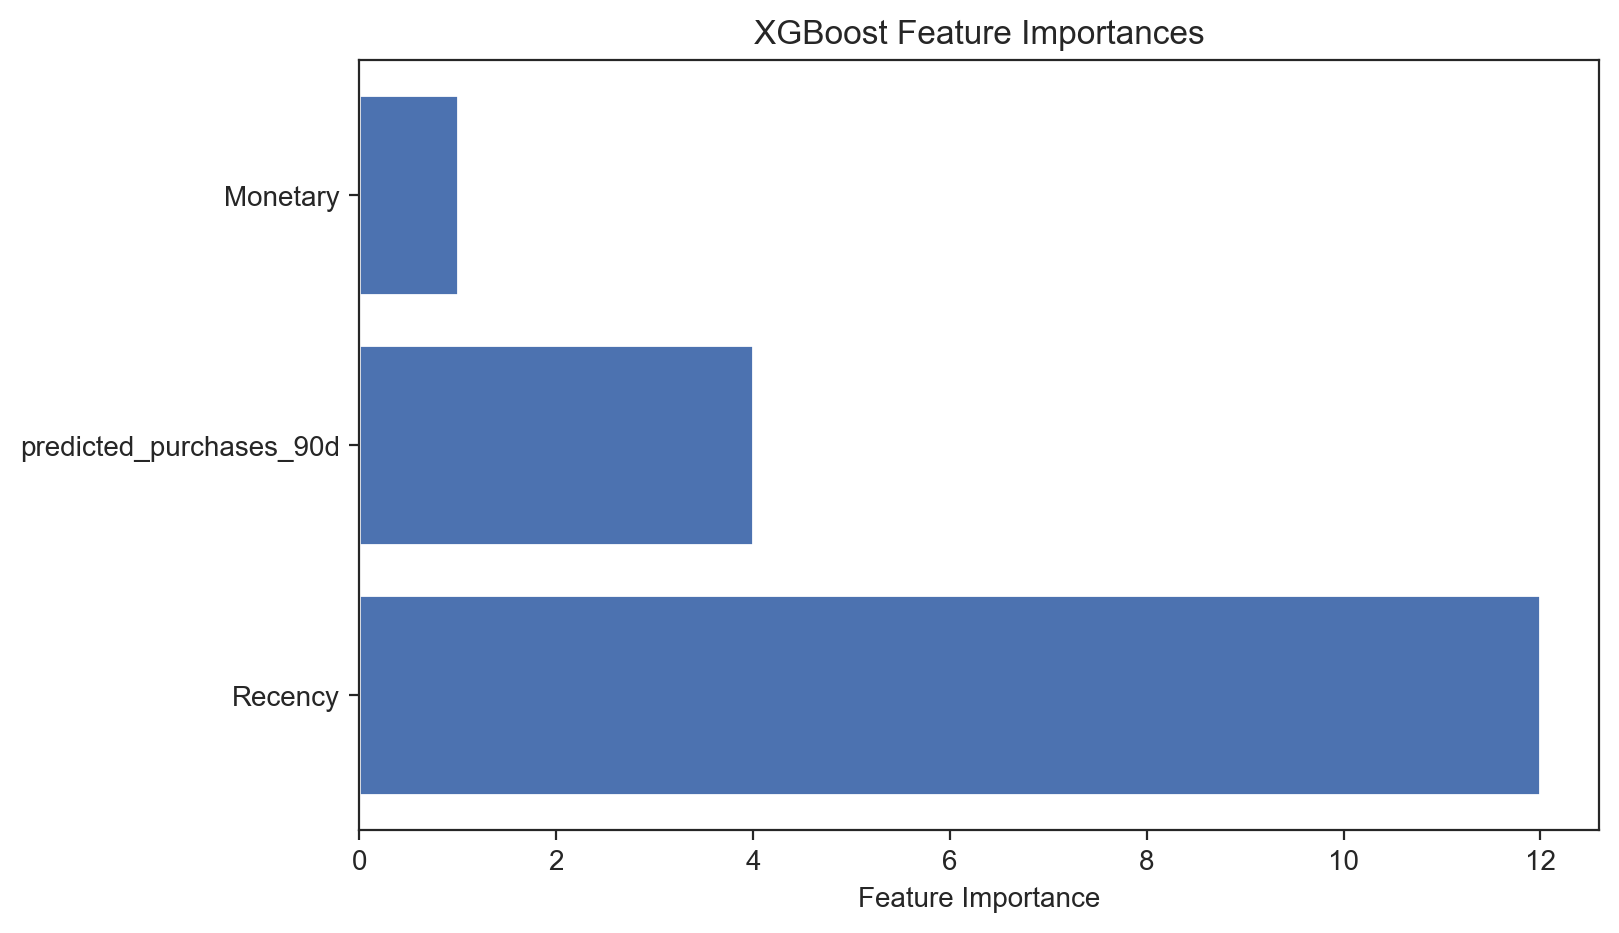

In [230]:
import xgboost as xgb

# Get feature importances from XGBoost model
xgb_feature_importances = best_xgb.get_booster().get_score(importance_type='weight')

# Plot feature importances
importances = sorted(xgb_feature_importances.items(), key=lambda x: x[1], reverse=True)
features, scores = zip(*importances)

plt.barh(features, scores)
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importances')
plt.show()

In [232]:
import joblib
joblib.dump(best_xgb, 'best_xgboost_model.pkl')

['best_xgboost_model.pkl']

In [234]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Random Forest
rf_cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Random Forest Cross-Validation Scores: {rf_cv_scores}")
print(f"Mean Cross-Validation Score: {np.mean(rf_cv_scores)}")

Random Forest Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean Cross-Validation Score: 1.0


In [236]:
# Cross-validation for XGBoost
xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='accuracy')
print(f"XGBoost Cross-Validation Scores: {xgb_cv_scores}")
print(f"Mean Cross-Validation Score: {np.mean(xgb_cv_scores)}")

XGBoost Cross-Validation Scores: [1. 1. 1. 1. 1.]
Mean Cross-Validation Score: 1.0


### Observation - Both models performed excellently. However XGBoost seem to slightly outperformed the other model since it maintains a perfect score across all cross-validation folds. Hence, a preferable model. 

## Apply K-Means Clustering on RFM data

In [240]:
['Recency', 'Frequency', 'Monetary']

['Recency', 'Frequency', 'Monetary']

In [242]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Extract RFM features
rfm_features = ['Recency', 'Frequency', 'Monetary']
rfm_data = clv_eval[rfm_features]

# Standardize the RFM data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clv_eval['cluster_label'] = kmeans.fit_predict(rfm_scaled)

In [244]:
# Analyze the cluster centers
cluster_centers = kmeans.cluster_centers_

# Create a DataFrame to make it easier to understand the cluster centers
cluster_centers_df = pd.DataFrame(cluster_centers, columns=rfm_features)

# Display the cluster centers
print("Cluster Centers (RFM Mean Values for Each Cluster):")
print(cluster_centers_df)

Cluster Centers (RFM Mean Values for Each Cluster):
    Recency  Frequency   Monetary
0 -0.567285  -0.101321  -0.075450
1  1.253263  -0.300804  -0.234330
2 -1.170686  13.452723  17.115833
3 -0.944969   2.036775   1.350027


In [246]:
# Define thresholds for each cluster based on mean RFM values
thresholds = {
    'Recency': {
        'low': cluster_centers_df['Recency'].min(),
        'high': cluster_centers_df['Recency'].max()
    },
    'Frequency': {
        'low': cluster_centers_df['Frequency'].min(),
        'high': cluster_centers_df['Frequency'].max()
    },
    'Monetary': {
        'low': cluster_centers_df['Monetary'].min(),
        'high': cluster_centers_df['Monetary'].max()
    }
}

print("Thresholds for Recency, Frequency, and Monetary:")
print(thresholds)

Thresholds for Recency, Frequency, and Monetary:
{'Recency': {'low': -1.1706858761654173, 'high': 1.2532628131465728}, 'Frequency': {'low': -0.3008037432151667, 'high': 13.452722984258566}, 'Monetary': {'low': -0.23433024925612736, 'high': 17.115833263431202}}


In [248]:
# Define a function to classify customers as high or low for each metric
def segment_customer(row, thresholds):
    segments = {}
    for feature in thresholds:
        if row[feature] <= thresholds[feature]['low']:
            segments[feature] = 'Low'
        elif row[feature] >= thresholds[feature]['high']:
            segments[feature] = 'High'
        else:
            segments[feature] = 'Medium'  # If it falls in between
    return segments

# Apply segmentation to each customer
clv_eval['customer_segment'] = clv_eval.apply(segment_customer, axis=1, thresholds=thresholds)

# Display the segmented customers
print("Customer Segments:")
print(clv_eval[['Recency', 'Frequency', 'Monetary', 'customer_segment']].head())

Customer Segments:
   Recency  Frequency   Monetary  \
0        8          7  431501.00   
1       81          4   82378.47   
2       25          1  176075.12   
3       42         11  241567.46   
4       29          3  161617.98   

                                    customer_segment  
0  {'Recency': 'High', 'Frequency': 'Medium', 'Mo...  
1  {'Recency': 'High', 'Frequency': 'Medium', 'Mo...  
2  {'Recency': 'High', 'Frequency': 'Medium', 'Mo...  
3  {'Recency': 'High', 'Frequency': 'Medium', 'Mo...  
4  {'Recency': 'High', 'Frequency': 'Medium', 'Mo...  


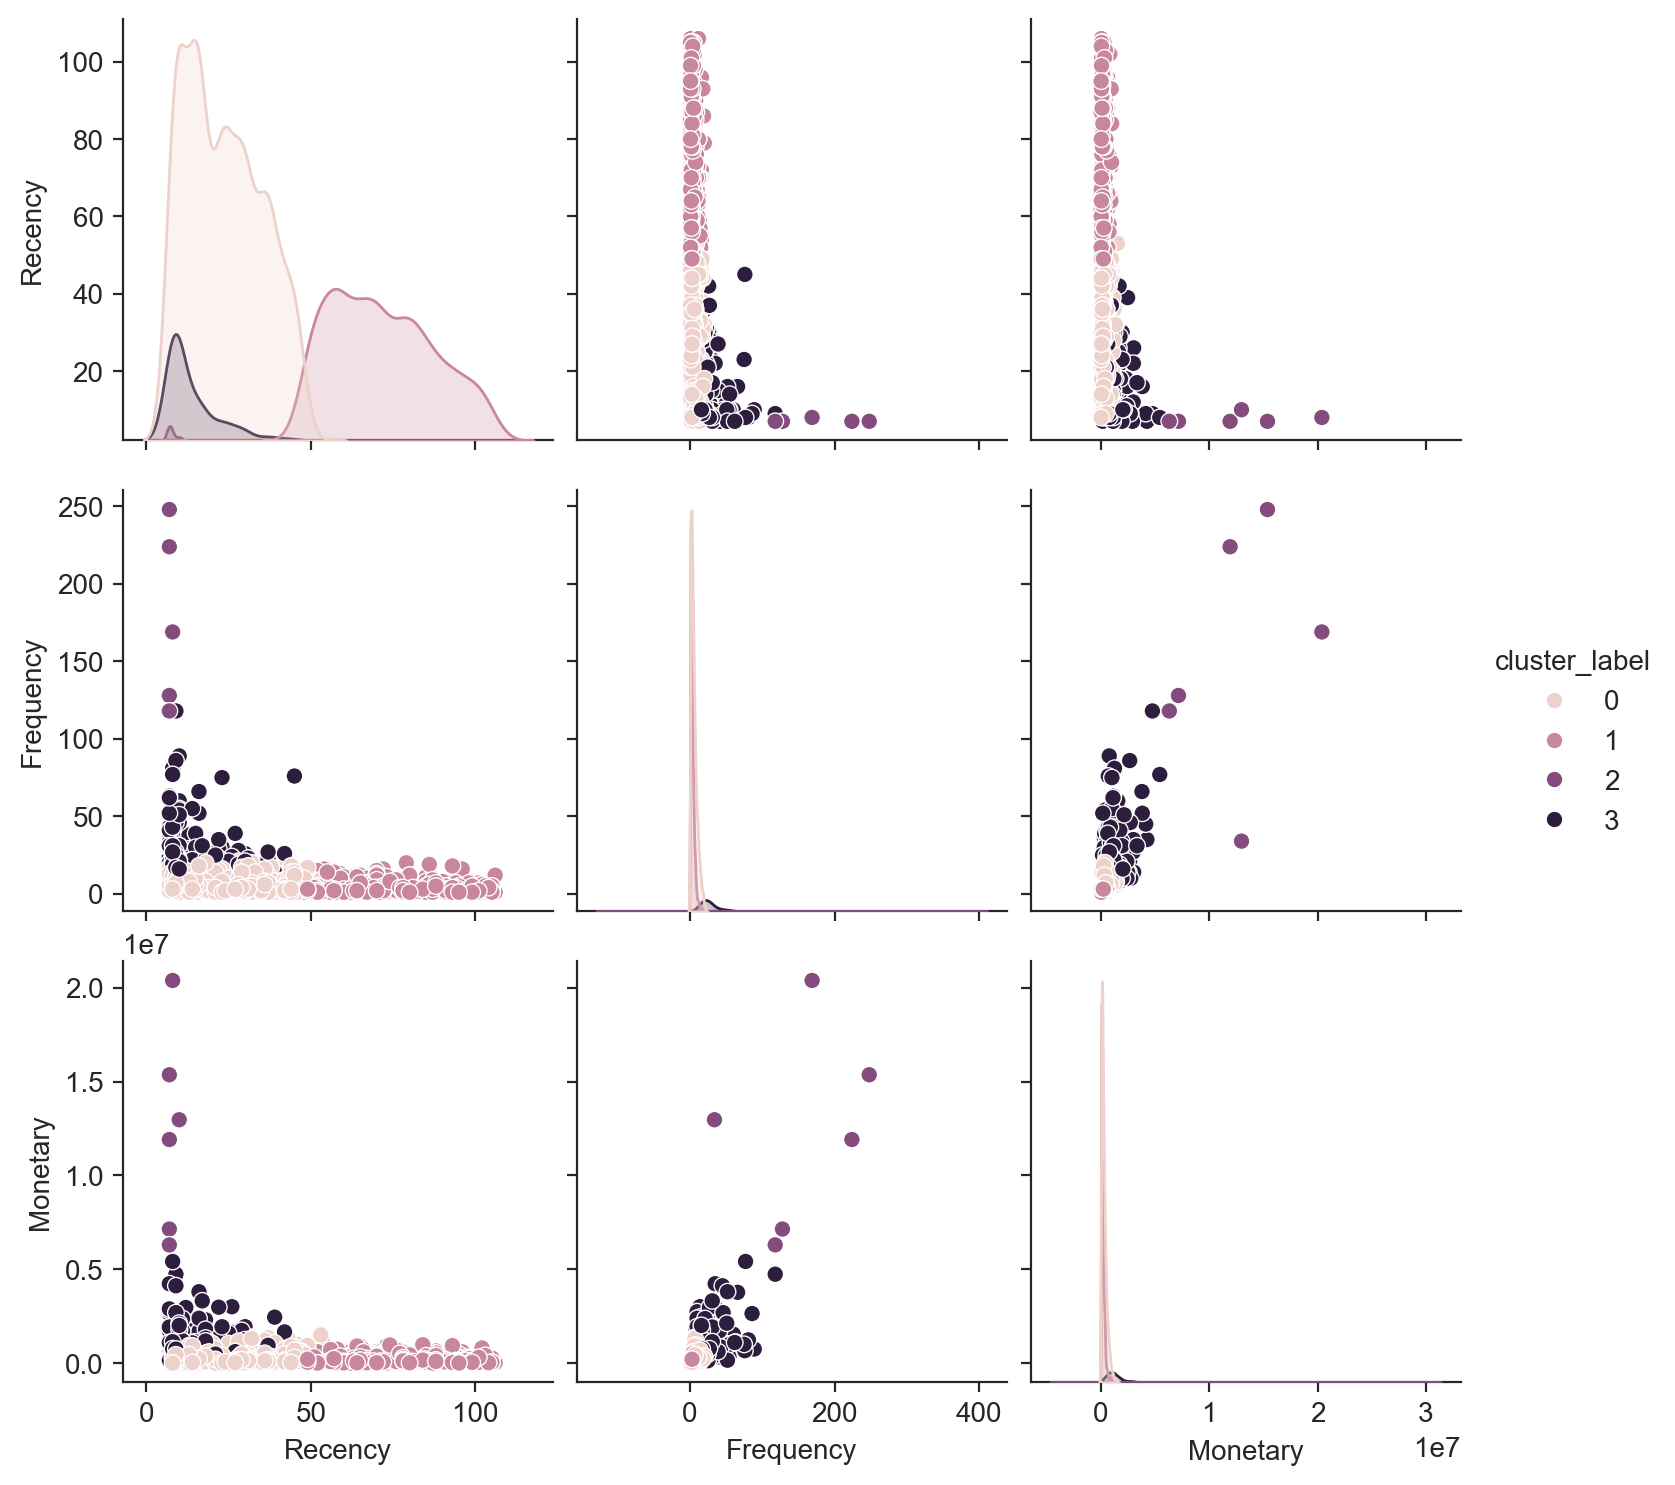

In [250]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure that the cluster_label column is part of the dataset (after KMeans clustering)
# Use 'clv_eval' instead of 'customer_data' to match the pipeline
sns.pairplot(clv_eval, hue='cluster_label', vars=['Recency', 'Frequency', 'Monetary'])
plt.show()

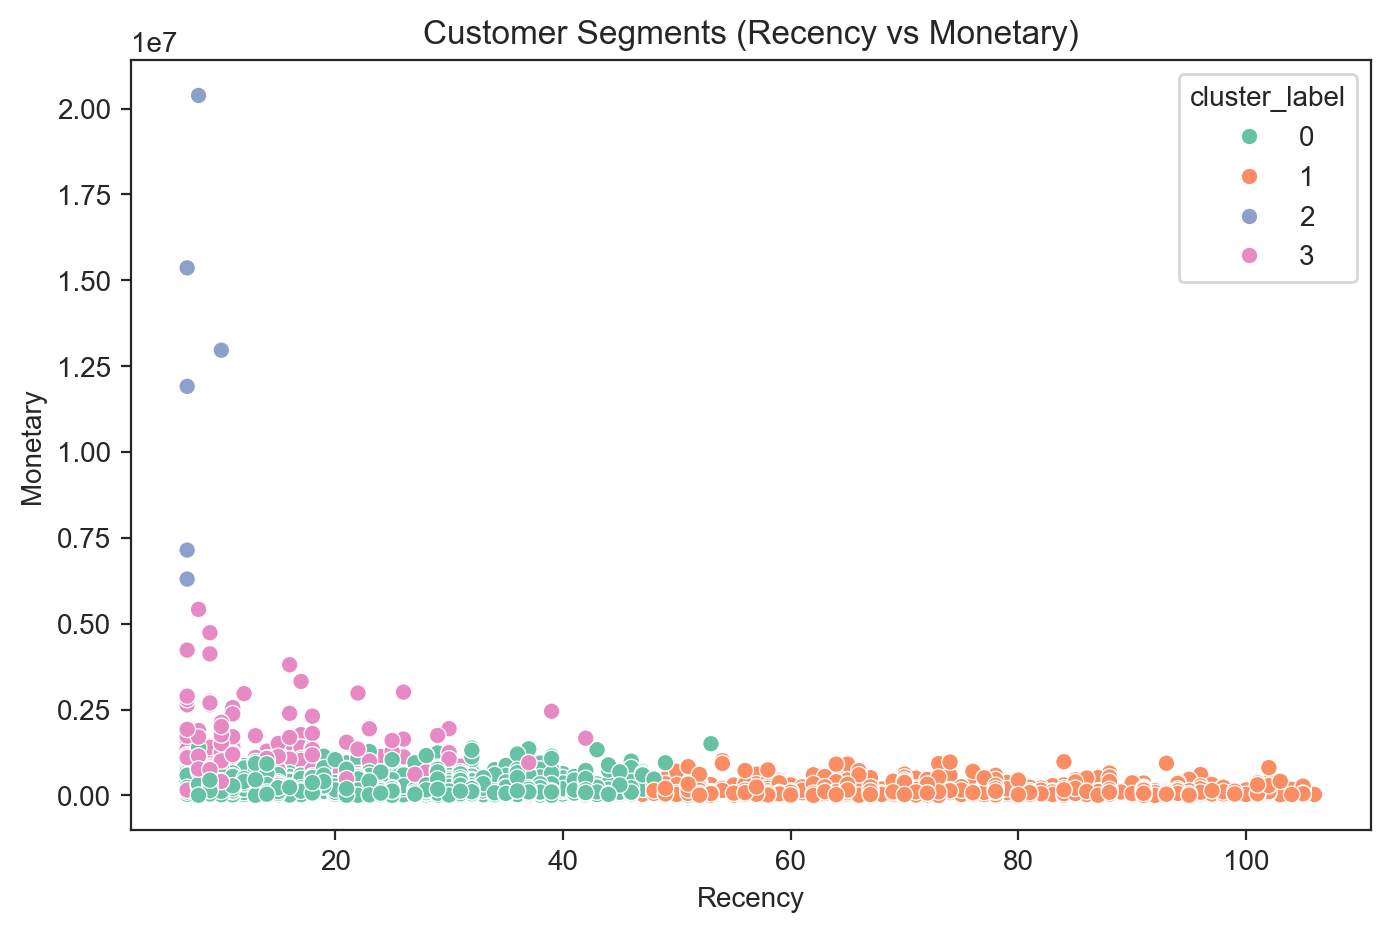

In [251]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'clv_eval' has the cluster labels
sns.scatterplot(data=clv_eval, x='Recency', y='Monetary', hue='cluster_label', palette='Set2')
plt.title("Customer Segments (Recency vs Monetary)")
plt.show()

In [254]:
clv_eval.head(2)

,CustomerID,Recency,Frequency,Monetary,T,predicted_purchases_90d,predicted_monetary,predicted_clv_90d,actual_spend_90d,IsChurned,cluster_label,customer_segment
0,12347,8,7,431501.00,373,1.797994e-11,455704.264565,0.000008,154300.83,False,0,"{'Recency': 'High', 'Frequency': 'Medium', 'Mo..."
1,12348,81,4,82378.47,364,1.044587e-02,90820.275724,948.696726,5162.79,False,1,"{'Recency': 'High', 'Frequency': 'Medium', 'Mo..."


In [256]:
# Feature selection: include cluster_label for retraining
features = ['Recency', 'Frequency', 'Monetary', 'predicted_purchases_90d', 'predicted_monetary', 'predicted_clv_90d', 'cluster_label']
X = clv_eval[features]
y = clv_eval['IsChurned']

In [258]:
# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data (important when features are on different scales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [260]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Random Forest Confusion Matrix:
[[588   0]
 [  0  12]]
Random Forest Accuracy Score: 1.0


In [262]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': np.arange(50, 301, 50),               
    'max_depth': [None, 10, 20, 30, 40],                   
    'min_samples_split': np.arange(2, 11, 1),              
    'min_samples_leaf': np.arange(1, 5, 1),                
    'max_features': ['auto', 'sqrt', 'log2'],            
    'bootstrap': [True, False]                            
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_dist, 
                                   n_iter=100, cv=3, verbose=2, random_state=42, 
                                   n_jobs=-1, scoring='accuracy')

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train_scaled, y_train)

# Print the best parameters and the best score found during RandomizedSearchCV
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: ", random_search.best_score_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best parameters found:  {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Best cross-validation score:  1.0


In [263]:
# Retrain the model with the best parameters found
best_rf_model = random_search.best_estimator_

# Evaluate the model on the test set
y_pred = best_rf_model.predict(X_test_scaled)

# Print classification report and accuracy score
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Random Forest Accuracy Score: 1.0


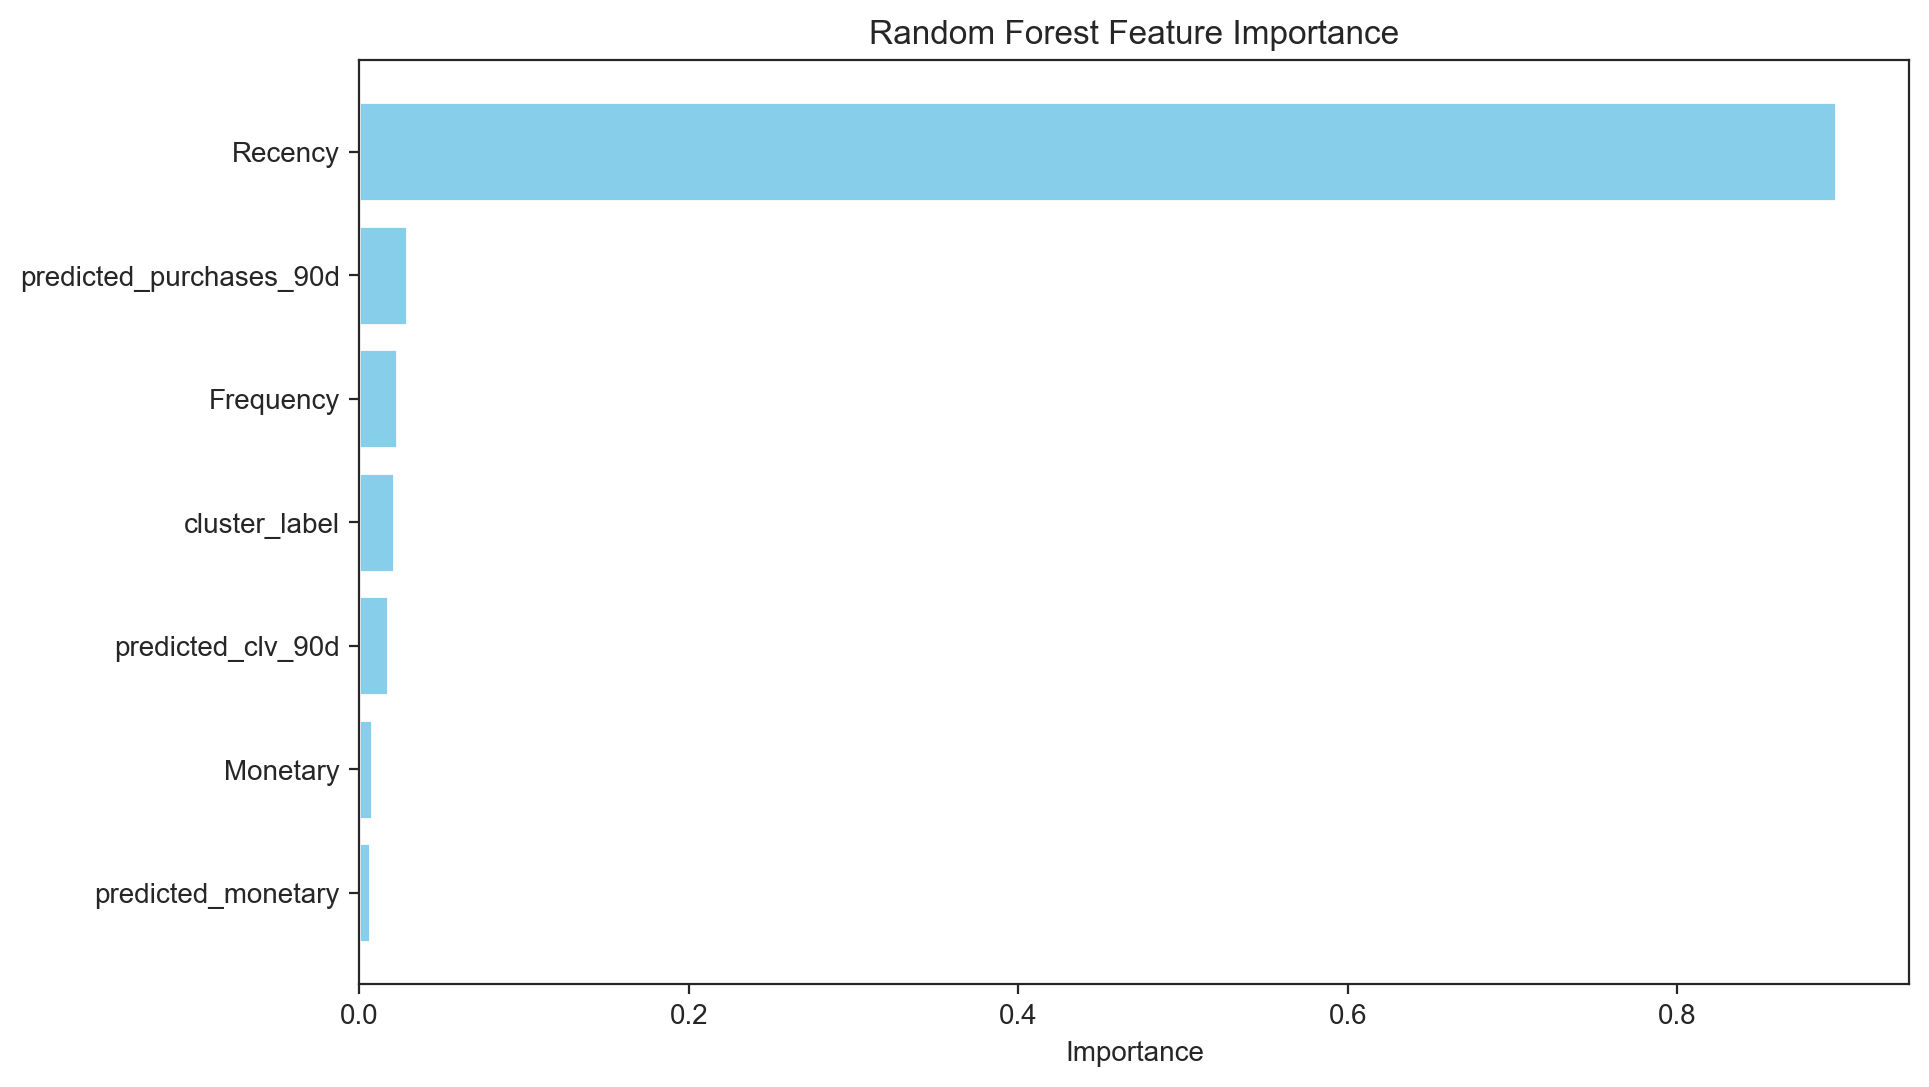

                   Feature  Importance
0                  Recency    0.896101
3  predicted_purchases_90d    0.028734
1                Frequency    0.022799
6            cluster_label    0.020887
5        predicted_clv_90d    0.017212


In [266]:
# Get feature importances from the best model
feature_importances = best_rf_model.feature_importances_

# Create a DataFrame with feature names and their corresponding importance
feature_names = X_train.columns  # Assuming you used the DataFrame for X_train
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()  # To display the most important feature on top
plt.show()

# Optionally, display the top features
print(feature_importance_df.head())

### Observation- Recency contributes far more to predicting churn than any of the other features. If a customer hasn’t purchased in a long time (i.e., high recency), the model is very likely to flag them as at risk of churn. If a customer purchased very recently, the model is very likely to predict they won’t churn. Therefore, prioritize recency-based interventions such as sending win-back campaigns to customers who haven't purchased recently and offering time-sensitive promotions to re-engage them. While Recency dominates, the others still add valuable nuance to edge cases or borderline predictions.

## Retraining XGBoost

In [269]:
# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define the hyperparameters to tune
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 2, 3, 4],
    'scale_pos_weight': [1, 2, 3]  # Useful for handling imbalanced classes
}

# Perform RandomizedSearchCV
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Fit the model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 2, 3, 4],
                                        'n_estimators': [100, 200, 300, 400],
                                        'scale_pos_weight': [1, 2, 3],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, verbose=1)

In [271]:
# Best model from RandomizedSearchCV
best_xgb_model = random_search.best_estimator_

# Predict on test data
y_pred = best_xgb_model.predict(X_test)

# Print accuracy and classification report
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred)}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

XGBoost Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       588
        True       1.00      1.00      1.00        12

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

Confusion Matrix:
[[588   0]
 [  0  12]]


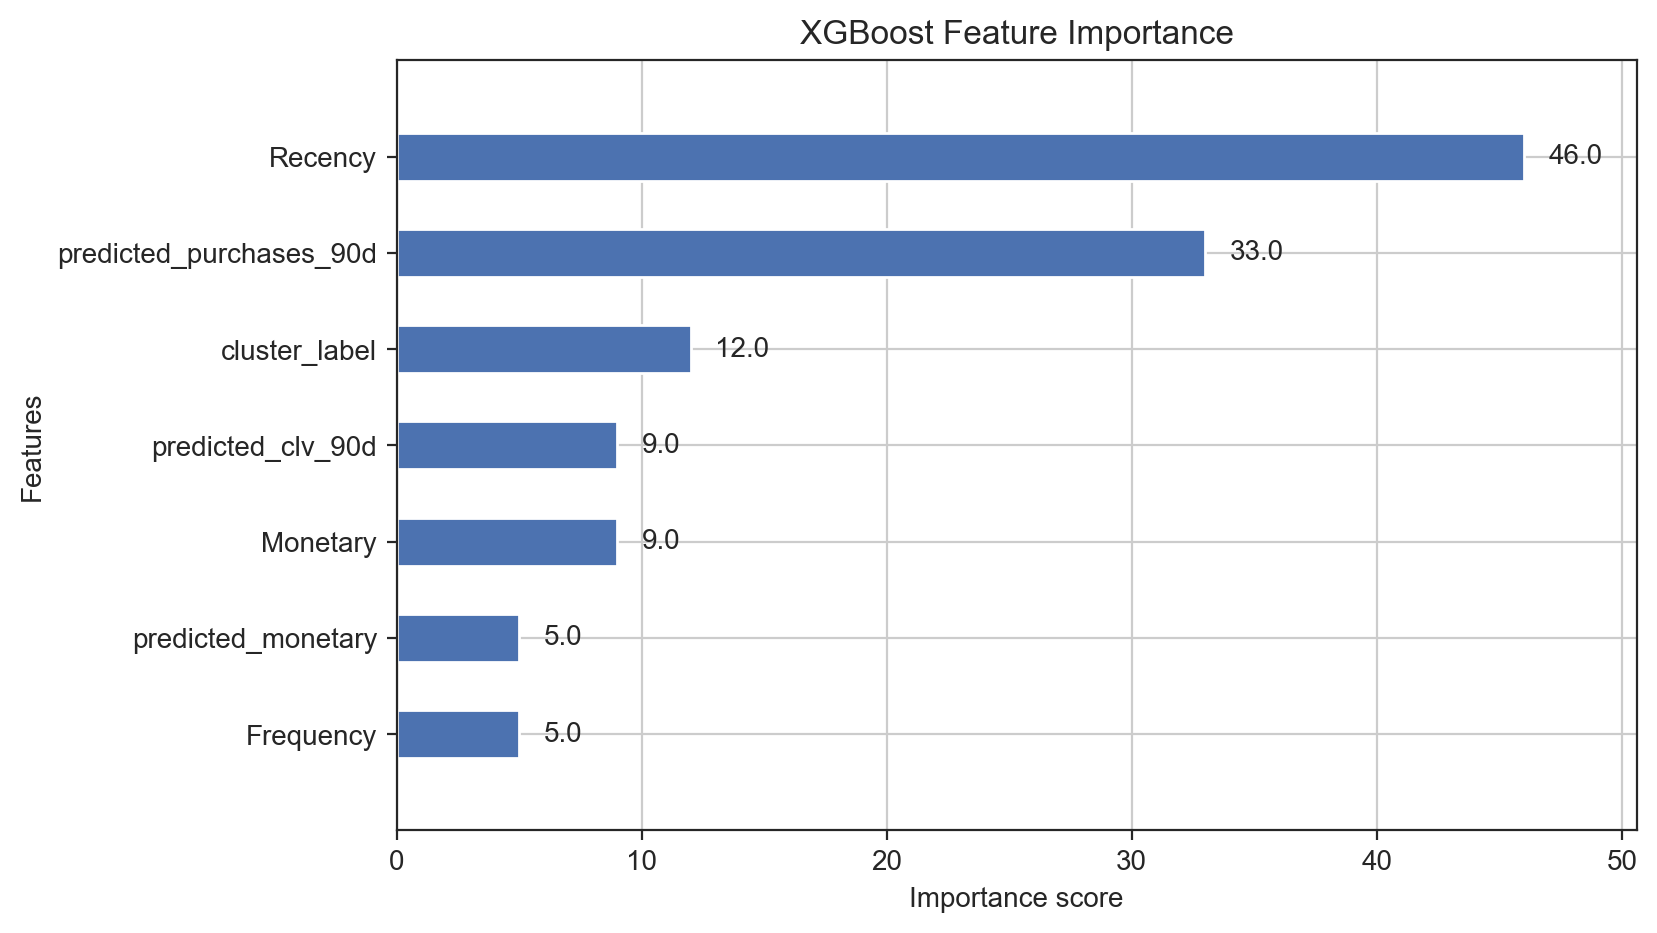

In [273]:
# Plot feature importance
xgb.plot_importance(best_xgb_model, importance_type='weight', max_num_features=10, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()